In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.fxlms_offline import OfflineFxLMS
from src.measure_ir import *

In [2]:
data = np.load('./data/poster_normal_irs.npz')

error_learning = data['error_learning']
ref_learning = data['ref_learning']

error_frozen = data['error_frozen']
ref_frozen = data['ref_frozen']

error_foam = data['error_foam']
ref_foam = data['ref_foam']

error_opt_frozen = data['error_opt_frozen']
ref_opt_frozen = data['ref_opt_frozen']

error_opt_learning = data['error_opt_learning']
ref_opt_learning = data['ref_opt_learning']

cancel_gain_opt = data['cancel_gain_opt']
weights_from_opt = data['weights_from_opt']
w_norm_from_opt = data['w_norm_from_opt']

error_nc = data['error_nc']
ref_nc = data['ref_nc']
source = data['source']

error_ir = data['error_ir']
ref_ir = data['ref_ir']
error_ir_raw = data['error_ir_raw']
ref_ir_raw = data['ref_ir_raw']

learned_weights = data['learned_weights']
w_norm_log = data['w_norm_log']
w_norm = data['w_norm']

w_ls = data['w_ls']

n_repeats = int(data['n_repeats'])
fs = int(data['fs'])
ir_len = int(data['ir_len'])
panel_to_err_cm = float(data['panel_to_err_cm'])

mu = float(data['mu'])
leak = float(data['leak'])
eps = float(data['eps'])
lag = int(data['lag'])
cancel_gain = float(data['cancel_gain'])
ref_threshold = float(data['ref_threshold'])
mavg_tau_ms = float(data['mavg_tau_ms'])
update_sign = float(data['update_sign'])

In [3]:
fx = OfflineFxLMS(
    M=len(learned_weights),
    error_ir=error_ir,
    ref_ir=ref_ir,
    fs=fs,
    nlms=True,
)

fx.set(
    mu=mu,
    leak=leak,
    eps=eps,
    lag=lag,
    cancel_gain=cancel_gain,
    ref_threshold=ref_threshold,
    mavg_tau_ms=mavg_tau_ms,
    update_sign=update_sign
)

Simulated ANC / No ANC: -9.93 dB


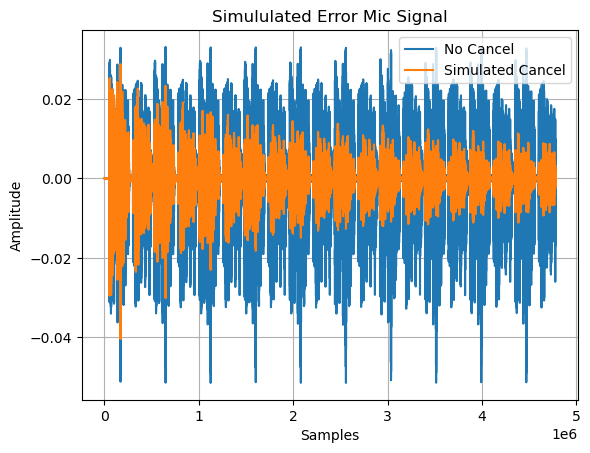

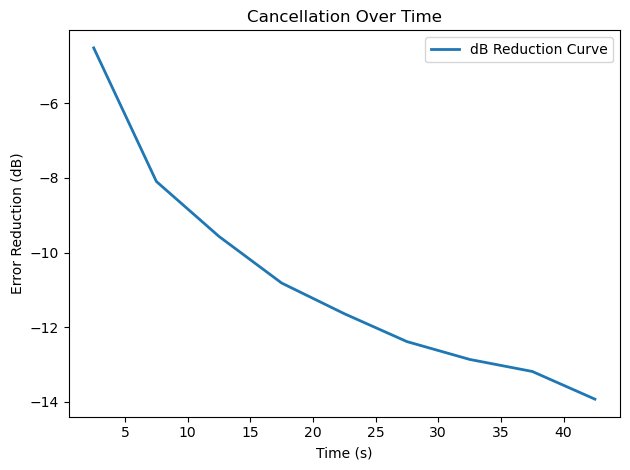

In [4]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, 
    adapt=True, clean_feedback=False, plot=True,
    mu=5e-3, leak=1e-7,
    poison_ref=False
)

Simulated ANC / No ANC: -10.07 dB


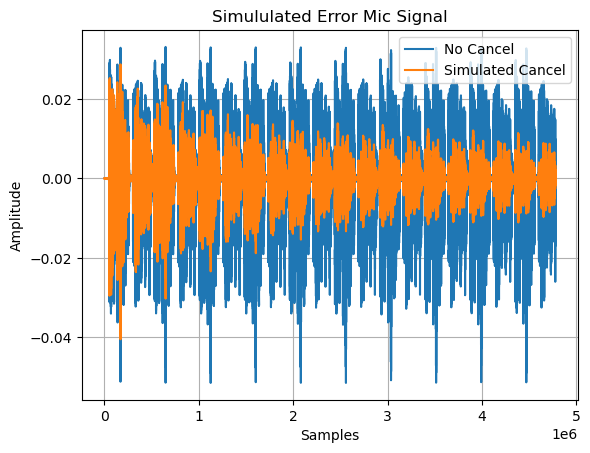

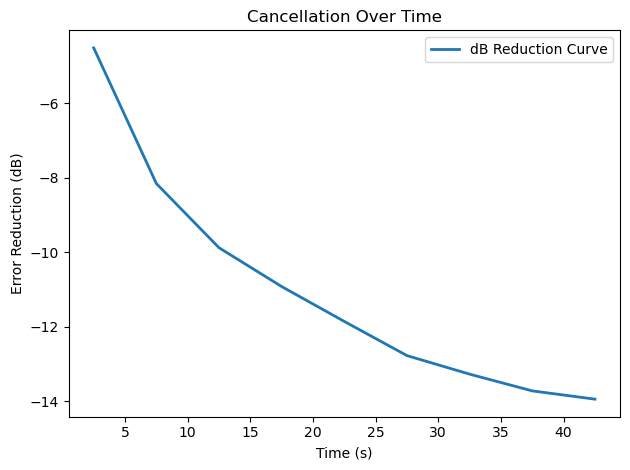

In [6]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, 
    adapt=True, clean_feedback=False, plot=True,
    mu=5e-3, leak=1e-7,
    poison_ref=True
)

Simulated ANC / No ANC: -10.02 dB


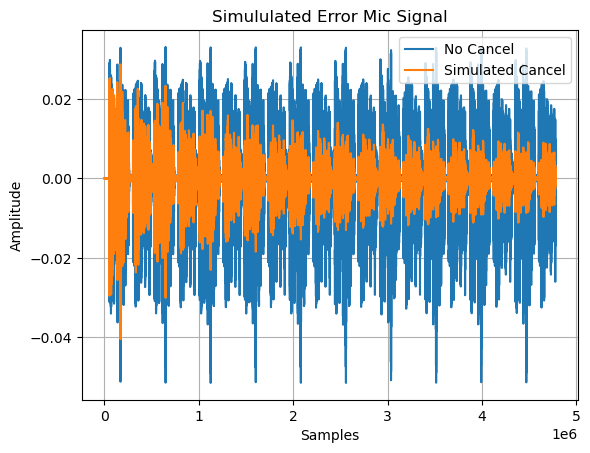

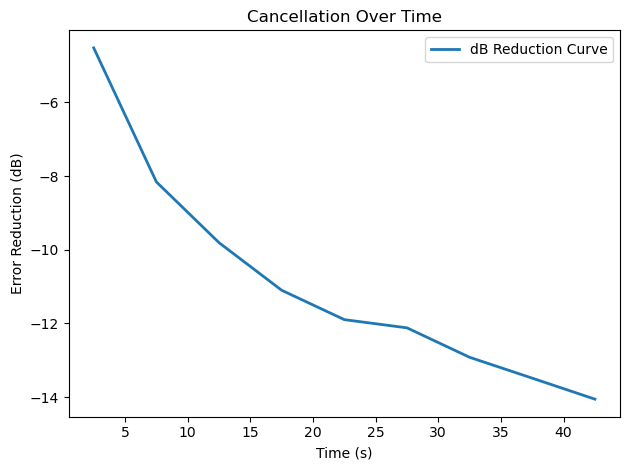

In [7]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, 
    adapt=True, clean_feedback=True, plot=True,
    mu=5e-3, leak=1e-7,
    poison_ref=True
)

Simulated ANC / No ANC: -10.07 dB


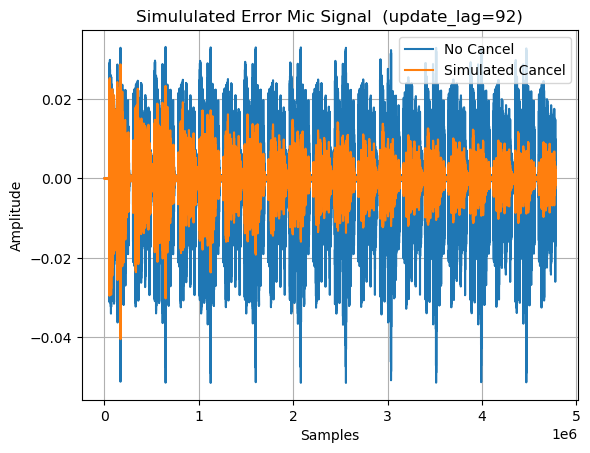

In [4]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, 
    adapt=True, clean_feedback=True, plot=True,
    mu=5e-3, leak=1e-7
)

Simulated ANC / No ANC: 3.46 dB


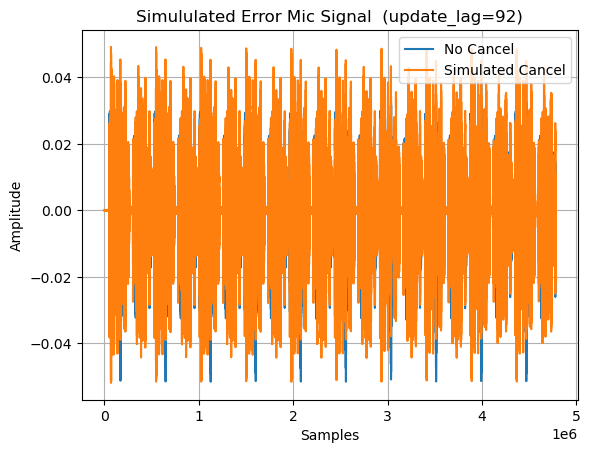

In [6]:
fx.reset()
fx.w = learned_weights
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, 
    adapt=False, clean_feedback=False, plot=True, mu=0.0
)


========== POSTER RESULTS ==========

Baseline RMS:           0.005971
Real-time ANC RMS:      0.003053
Offline ANC RMS:        0.001873

Real-time reduction:    -5.83 dB
Offline reduction:      -10.07 dB

Real-time RMS decrease: 48.9%
Offline RMS decrease:   68.6%

Real-time reduction by repetition:
  Rep  1:  -3.56 dB
  Rep  2:  -5.93 dB
  Rep  3:  -6.10 dB
  Rep  4:  -6.14 dB
  Rep  5:  -6.15 dB
  Rep  6:  -6.25 dB
  Rep  7:  -6.13 dB
  Rep  8:  -6.29 dB
  Rep  9:  -6.26 dB
  Rep 10:  -6.34 dB
  Mean: -5.92 dB +/- 0.84 dB

Offline reduction by repetition:
  Rep  1:  -4.52 dB
  Rep  2:  -8.19 dB
  Rep  3:  -9.90 dB
  Rep  4: -11.03 dB
  Rep  5: -12.03 dB
  Rep  6: -12.69 dB
  Rep  7: -13.05 dB
  Rep  8: -13.46 dB
  Rep  9: -13.83 dB
  Rep 10: -14.24 dB
  Mean: -11.29 dB +/- 3.04 dB


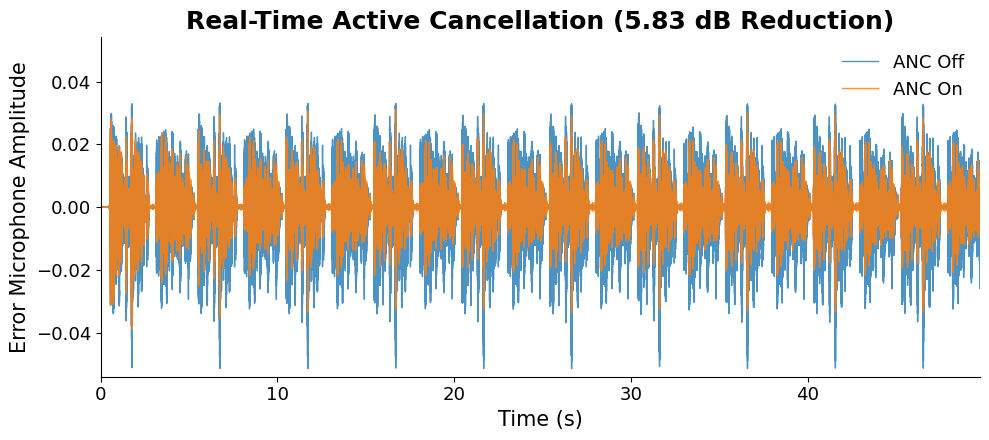

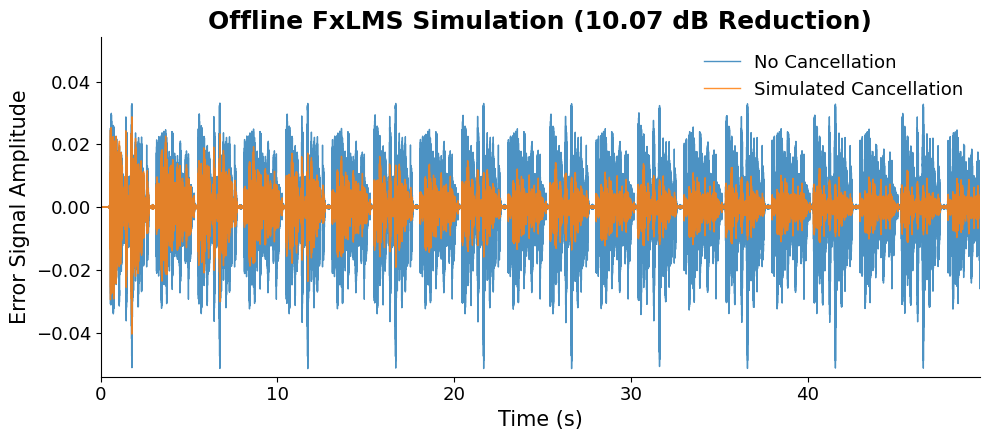

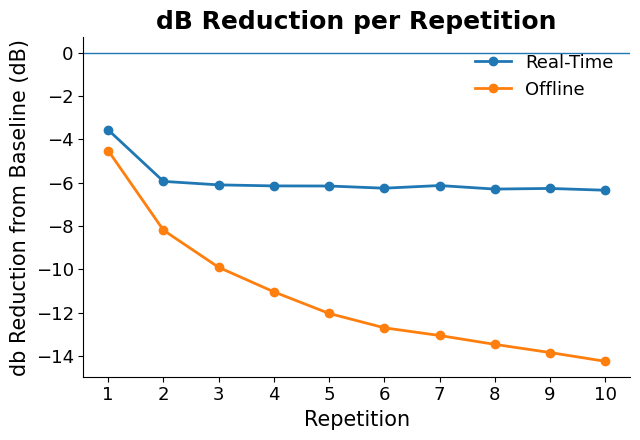

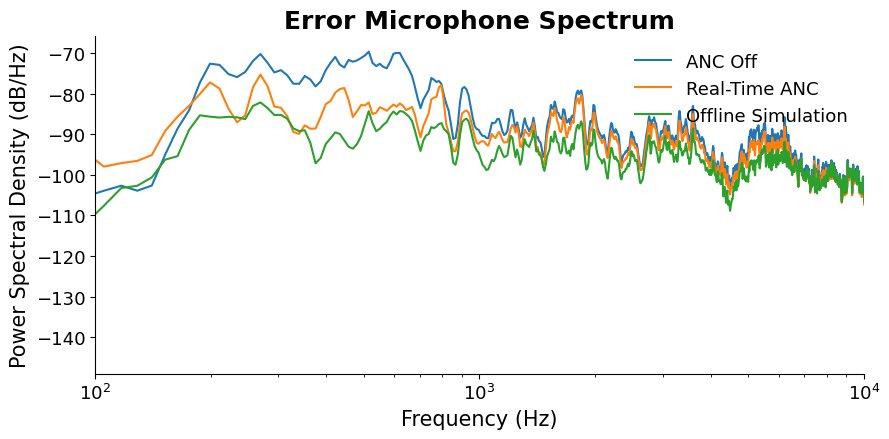

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ============================================================
# SETTINGS
# ============================================================

N_REPEATS = 10

# Poster-friendly sizing
FIGSIZE = (10, 4.5)
TITLE_SIZE = 18
LABEL_SIZE = 15
TICK_SIZE = 13
LEGEND_SIZE = 13
LINEWIDTH = 1.0


# ============================================================
# METRICS
# ============================================================

def rms(x):
    x = np.asarray(x)
    return np.sqrt(np.mean(x**2))


def reduction_db(cancelled, baseline):
    """
    Negative = reduction.
    Example: -5 dB means cancelled signal has 5 dB less power.
    """
    return 10 * np.log10(
        (np.mean(cancelled**2) + 1e-20) /
        (np.mean(baseline**2) + 1e-20)
    )


def rms_reduction_percent(cancelled, baseline):
    return 100 * (1 - rms(cancelled) / rms(baseline))


def repeat_reductions(cancelled, baseline, n_repeats=10):
    N = min(len(cancelled), len(baseline))
    rep_len = N // n_repeats

    vals = []

    for i in range(n_repeats):
        a = i * rep_len
        b = (i + 1) * rep_len

        vals.append(
            reduction_db(cancelled[a:b], baseline[a:b])
        )

    return np.array(vals)


# ============================================================
# TRIM ALL SIGNALS TO COMMON LENGTH
# ============================================================

N = min(
    len(error_nc),
    len(error_learning),
    len(simulated_error)
)

baseline = np.asarray(error_nc[:N])
online = np.asarray(error_learning[:N])
offline = np.asarray(simulated_error[:N])

t = np.arange(N) / fs


# ============================================================
# CALCULATE METRICS
# ============================================================

baseline_rms = rms(baseline)
online_rms = rms(online)
offline_rms = rms(offline)

online_db = reduction_db(online, baseline)
offline_db = reduction_db(offline, baseline)

online_pct = rms_reduction_percent(online, baseline)
offline_pct = rms_reduction_percent(offline, baseline)

online_reps = repeat_reductions(
    online, baseline, N_REPEATS
)

offline_reps = repeat_reductions(
    offline, baseline, N_REPEATS
)


print("\n========== POSTER RESULTS ==========\n")

print(f"Baseline RMS:           {baseline_rms:.6f}")
print(f"Real-time ANC RMS:      {online_rms:.6f}")
print(f"Offline ANC RMS:        {offline_rms:.6f}")

print()

print(f"Real-time reduction:    {online_db:.2f} dB")
print(f"Offline reduction:      {offline_db:.2f} dB")

print()

print(f"Real-time RMS decrease: {online_pct:.1f}%")
print(f"Offline RMS decrease:   {offline_pct:.1f}%")

print("\nReal-time reduction by repetition:")
for i, val in enumerate(online_reps, 1):
    print(f"  Rep {i:2d}: {val:6.2f} dB")

print(
    f"  Mean: {online_reps.mean():.2f} dB "
    f"+/- {online_reps.std(ddof=1):.2f} dB"
)

print("\nOffline reduction by repetition:")
for i, val in enumerate(offline_reps, 1):
    print(f"  Rep {i:2d}: {val:6.2f} dB")

print(
    f"  Mean: {offline_reps.mean():.2f} dB "
    f"+/- {offline_reps.std(ddof=1):.2f} dB"
)


# ============================================================
# COMMON Y LIMIT
# Makes online/offline plots visually comparable
# ============================================================

ylim = 1.05 * max(
    np.max(np.abs(baseline)),
    np.max(np.abs(online)),
    np.max(np.abs(offline))
)


# ============================================================
# FIGURE 1 — REAL-TIME HARDWARE
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(
    t,
    baseline,
    label="ANC Off",
    linewidth=LINEWIDTH,
    alpha=0.8
)

ax.plot(
    t,
    online,
    label="ANC On",
    linewidth=LINEWIDTH,
    alpha=0.85
)

ax.set_title(
    f"Real-Time Active Cancellation ({-online_db:.2f} dB Reduction)",
    fontsize=TITLE_SIZE,
    fontweight="bold"
)

ax.set_xlabel("Time (s)", fontsize=LABEL_SIZE)
ax.set_ylabel("Error Microphone Amplitude", fontsize=LABEL_SIZE)

ax.set_xlim(t[0], t[-1])
ax.set_ylim(-ylim, ylim)

ax.tick_params(labelsize=TICK_SIZE)
ax.legend(fontsize=LEGEND_SIZE, frameon=False, loc='upper right')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

plt.savefig(
    "poster_realtime_cancellation.svg",
    bbox_inches="tight"
)

plt.savefig(
    "poster_realtime_cancellation.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 2 — OFFLINE SIMULATION
# ============================================================

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.plot(
    t,
    baseline,
    label="No Cancellation",
    linewidth=LINEWIDTH,
    alpha=0.8
)

ax.plot(
    t,
    offline,
    label="Simulated Cancellation",
    linewidth=LINEWIDTH,
    alpha=0.85
)

ax.set_title(
    f"Offline FxLMS Simulation ({-offline_db:.2f} dB Reduction)",
    fontsize=TITLE_SIZE,
    fontweight="bold"
)

ax.set_xlabel("Time (s)", fontsize=LABEL_SIZE)
ax.set_ylabel("Error Signal Amplitude", fontsize=LABEL_SIZE)

ax.set_xlim(t[0], t[-1])
ax.set_ylim(-ylim, ylim)

ax.tick_params(labelsize=TICK_SIZE)
ax.legend(fontsize=LEGEND_SIZE, frameon=False, loc='upper right')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

plt.savefig(
    "poster_offline_cancellation.svg",
    bbox_inches="tight"
)

plt.savefig(
    "poster_offline_cancellation.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 3 — REDUCTION BY REPETITION
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 4.5))

reps = np.arange(1, N_REPEATS + 1)

ax.plot(
    reps,
    online_reps,
    marker="o",
    linewidth=2,
    label="Real-Time"
)

ax.plot(
    reps,
    offline_reps,
    marker="o",
    linewidth=2,
    label="Offline"
)

ax.axhline(0, linewidth=1)

ax.set_xlabel("Repetition", fontsize=LABEL_SIZE)
ax.set_ylabel("db Reduction from Baseline (dB)", fontsize=LABEL_SIZE)

ax.set_title(
    "dB Reduction per Repetition",
    fontsize=TITLE_SIZE,
    fontweight="bold"
)

ax.set_xticks(reps)
ax.tick_params(labelsize=TICK_SIZE)

ax.legend(fontsize=LEGEND_SIZE, frameon=False, loc='upper right')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

plt.savefig(
    "poster_repetition_reduction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "poster_repetition_reduction.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FIGURE 4 — PSD
# ============================================================

nperseg = 8192

f, P_nc = welch(
    baseline,
    fs=fs,
    nperseg=nperseg
)

_, P_online = welch(
    online,
    fs=fs,
    nperseg=nperseg
)

_, P_offline = welch(
    offline,
    fs=fs,
    nperseg=nperseg
)

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.semilogx(
    f,
    10 * np.log10(P_nc + 1e-20),
    label="ANC Off",
    linewidth=1.5
)

ax.semilogx(
    f,
    10 * np.log10(P_online + 1e-20),
    label="Real-Time ANC",
    linewidth=1.5
)

ax.semilogx(
    f,
    10 * np.log10(P_offline + 1e-20),
    label="Offline Simulation",
    linewidth=1.5
)

ax.set_xlim(100, min(10000, fs / 2))

ax.set_xlabel("Frequency (Hz)", fontsize=LABEL_SIZE)
ax.set_ylabel("Power Spectral Density (dB/Hz)", fontsize=LABEL_SIZE)

ax.set_title(
    "Error Microphone Spectrum",
    fontsize=TITLE_SIZE,
    fontweight="bold"
)

ax.tick_params(labelsize=TICK_SIZE)
ax.legend(fontsize=LEGEND_SIZE, frameon=False, loc='upper right')

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

plt.savefig(
    "poster_error_spectrum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "poster_error_spectrum.pdf",
    bbox_inches="tight"
)

plt.show()

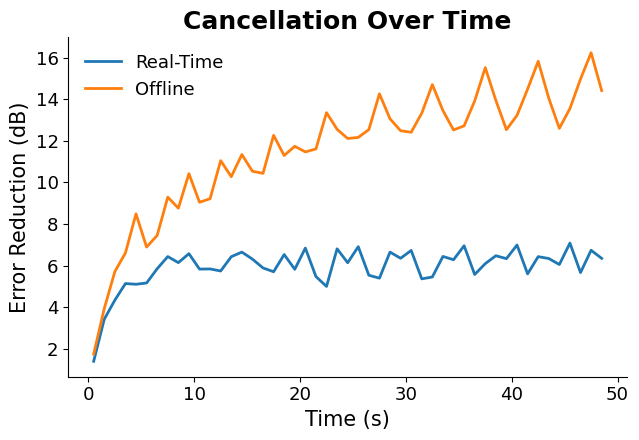

In [22]:
def reduction_over_time(cancelled, baseline, fs,
                        window_sec=5.0, hop_sec=5.0):

    N = min(len(cancelled), len(baseline))

    win = int(window_sec * fs)
    hop = int(hop_sec * fs)

    times = []
    reductions = []

    for start in range(0, N - win + 1, hop):
        end = start + win

        reductions.append(
            reduction_db(
                cancelled[start:end],
                baseline[start:end]
            )
        )

        # center of window
        times.append((start + win / 2) / fs)

    return np.array(times), np.array(reductions)


# Calculate time-resolved reduction
t_online, online_loss = reduction_over_time(
    online, baseline, fs,
    window_sec=1,
    hop_sec=1
)

t_offline, offline_loss = reduction_over_time(
    offline, baseline, fs,
    window_sec=1,
    hop_sec=1
)


# Plot
fig, ax = plt.subplots(figsize=(6.5, 4.5))

online_loss = -online_loss
offline_loss = -offline_loss

ax.plot(t_online, online_loss, linewidth=2, label="Real-Time")
ax.plot(t_offline, offline_loss, linewidth=2, label="Offline")

ax.set_xlabel("Time (s)", fontsize=LABEL_SIZE)
ax.set_ylabel("Error Reduction (dB)", fontsize=LABEL_SIZE)
ax.set_title(
    "Cancellation Over Time",
    fontsize=TITLE_SIZE,
    fontweight="bold"
)

ax.tick_params(labelsize=TICK_SIZE)
ax.legend(fontsize=LEGEND_SIZE, frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

plt.savefig(
    "poster_cancellation_over_time.svg",
    bbox_inches="tight"
)

plt.show()

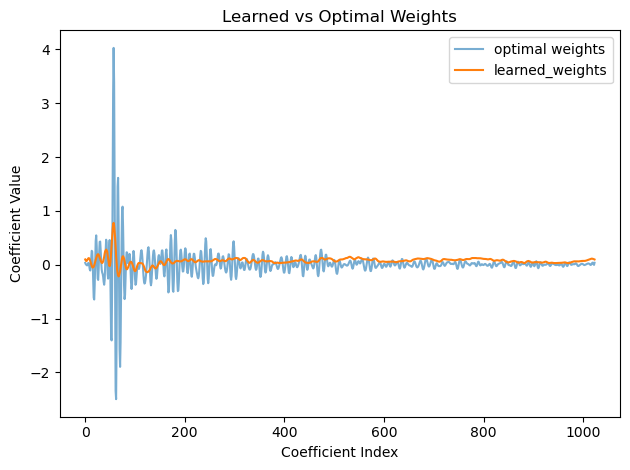

In [30]:
plt.plot(w_ls, label='optimal weights', alpha=0.6)
plt.plot(learned_weights, label='learned_weights', linewidth=1.5)

plt.title('Learned vs Optimal Weights')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Value')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# data = np.load('./data/learned.npz')

# error_nc = data['error_nc']
# ref_nc = data['ref_nc']
# error_ir = data['error_ir']
# ref_ir = data['ref_ir']
# learned_weights = data['learned_w']
# w_ls = data['w_ls']

# mu = float(data['mu'])
# cancel_gain = float(data['cancel_gain'])
# leak = float(data['leak'])
# clean_feedback = bool(data['clean_feedback'])
# lag = int(data['lag'])
# fs = int(data['fs'])




In [ ]:
# fx = OfflineFxLMS(
#     M=len(learned_weights),
#     error_ir=error_ir,
#     ref_ir=ref_ir,
#     fs=fs,
#     nlms=True,
# )

# fx.set(
#     mu=mu,
#     leak=leak,
#     lag=lag,
#     cancel_gain=cancel_gain,
# )

In [ ]:
import numpy as np
from scipy.signal import lfilter


def least_squares_controller(
    ref_nc,
    error_nc,
    error_ir,
    M=1024,
    system_delay=86,
    cancel_gain=0.11,
    ridge=1e-2,
    trim=5000,
):
    """
    Find the optimal fixed M-tap controller for:

        control[n] = -cancel_gain * sum_k w[k] * ref[n-k]

        panel[n] = error_ir * control[n-system_delay]

        simulated_error[n] = error_nc[n] + panel[n]

    This matches the timing/sign convention of OfflineFxLMS.process_array().
    """

    x = np.asarray(ref_nc, dtype=np.float64)
    d = np.asarray(error_nc, dtype=np.float64)
    s = np.asarray(error_ir, dtype=np.float64)

    N = min(len(x), len(d))
    x = x[:N]
    d = d[:N]

    # Filtered reference through the measured secondary path.
    xf = lfilter(s, [1.0], x)

    # Explicit system latency, exactly like process_array().
    xf_delayed = np.zeros_like(xf)

    if system_delay > 0:
        xf_delayed[system_delay:] = xf[:-system_delay]
    else:
        xf_delayed[:] = xf

    # Throw away startup/transient region.
    start = max(trim, system_delay + len(s) + M)
    stop = N

    y = d[start:stop]

    # Build X such that:
    #
    # X @ w = sum_k w[k] * xf_delayed[n-k]
    #
    # Then actual panel contribution is:
    #
    #     -cancel_gain * X @ w
    #
    # We want:
    #
    #     d - cancel_gain * X @ w ~= 0

    from numpy.lib.stride_tricks import sliding_window_view

    windows = sliding_window_view(xf_delayed, M)

    # windows[j] = [xf[j], ..., xf[j+M-1]]
    # Reverse so each row is:
    # [xf[n], xf[n-1], ..., xf[n-M+1]]

    X_all = windows[:, ::-1]

    # Row corresponding to time n has index n-M+1.
    row_start = start - M + 1
    row_stop = stop - M + 1

    X = X_all[row_start:row_stop]

    assert len(X) == len(y)

    # Solve:
    #
    # min_w || d - cancel_gain*Xw ||^2 + ridge*||w||^2
    #
    # Divide the target by gain so the regression is:
    #
    # Xw ~= d / cancel_gain

    target = y / cancel_gain

    XtX = X.T @ X
    Xty = X.T @ target

    w = np.linalg.solve(
        XtX + ridge * np.eye(M),
        Xty,
    )

    # Evaluate using the SAME forward model.
    controller_raw = lfilter(w, [1.0], x)
    control = -cancel_gain * controller_raw

    delayed_control = np.zeros_like(control)

    if system_delay > 0:
        delayed_control[system_delay:] = control[:-system_delay]
    else:
        delayed_control[:] = control

    panel = lfilter(s, [1.0], delayed_control)

    simulated_error = d + panel

    # Evaluate over same region used for fitting.
    d_eval = d[start:stop]
    e_eval = simulated_error[start:stop]

    db = 10 * np.log10(
        (np.mean(e_eval**2) + 1e-20) /
        (np.mean(d_eval**2) + 1e-20)
    )

    print(f"system delay: {system_delay} samples")
    print(f"LS reduction: {db:.2f} dB")
    print(f"weight norm: {np.linalg.norm(w):.4f}")

    return w, simulated_error, control, panel, db

Simulated ANC / No ANC: -4.38 dB


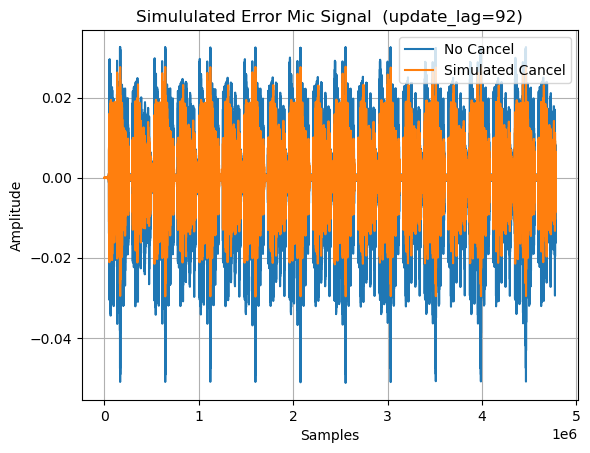

In [ ]:
# fx.reset()
# fx.w = learned_weights
# control, simulated_error, panel_output, weight_history = fx.process_array(
#     ref_nc, error_nc, 
#     adapt=False, clean_feedback=False, plot=True, mu=0.0, cancel_gain=0.05
# )

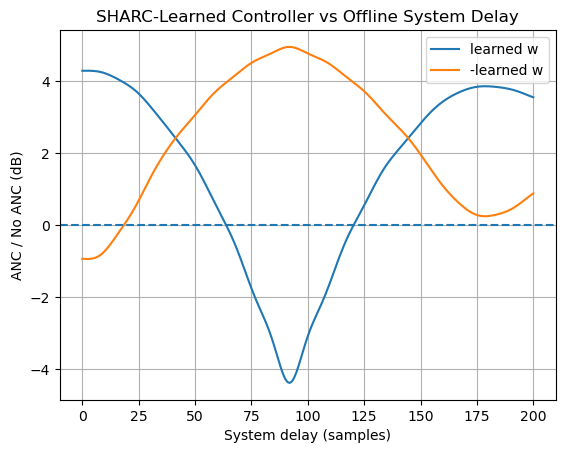

w:  best -4.38 dB at delay 92
-w: best -0.94 dB at delay 2


In [ ]:
# from scipy.signal import lfilter

# delays = np.arange(0, 201)

# db_pos = []
# db_neg = []

# for delay in delays:
#     for weights, results in [
#         (learned_weights, db_pos),
#         (-learned_weights, db_neg),
#     ]:
#         controller_raw = lfilter(weights, [1.0], ref_nc)
#         control = -0.05 * controller_raw

#         delayed_control = np.zeros_like(control)

#         if delay > 0:
#             delayed_control[delay:] = control[:-delay]
#         else:
#             delayed_control[:] = control

#         panel = lfilter(
#             np.asarray(error_ir).reshape(-1),
#             [1.0],
#             delayed_control
#         )

#         simulated_error = error_nc + panel

#         start = 5000

#         db = 10 * np.log10(
#             (np.mean(simulated_error[start:]**2) + 1e-20) /
#             (np.mean(error_nc[start:]**2) + 1e-20)
#         )

#         results.append(db)

# plt.figure()
# plt.plot(delays, db_pos, label="learned w")
# plt.plot(delays, db_neg, label="-learned w")
# plt.axhline(0, linestyle="--")
# plt.xlabel("System delay (samples)")
# plt.ylabel("ANC / No ANC (dB)")
# plt.title("SHARC-Learned Controller vs Offline System Delay")
# plt.grid(True)
# plt.legend()
# plt.show()

# i = np.argmin(db_pos)
# j = np.argmin(db_neg)

# print(f"w:  best {db_pos[i]:.2f} dB at delay {delays[i]}")
# print(f"-w: best {db_neg[j]:.2f} dB at delay {delays[j]}")

In [ ]:
# w = learned_weights
# delay = 92
# s = np.asarray(error_ir).reshape(-1)

# controller_raw = lfilter(w, [1.0], ref_nc)

# delayed = np.zeros_like(controller_raw)
# delayed[delay:] = controller_raw[:-delay]

# # This is the secondary-path output for controller gain = +1
# y = lfilter(s, [1.0], delayed)

# start = 5000
# d = error_nc[start:]
# y = y[start:]

# # Our convention is e = d - g*y
# g_opt = np.dot(d, y) / np.dot(y, y)

# e_opt = d - g_opt * y

# db_opt = 10 * np.log10(
#     (np.mean(e_opt**2) + 1e-20) /
#     (np.mean(d**2) + 1e-20)
# )

# print("optimal gain:", g_opt)
# print("reduction:", db_opt)

optimal gain: 0.046369988125052976
reduction: -4.427430662591781


In [ ]:
# delays = np.arange(0, 201)

# best_gain = []
# best_db = []

# controller_raw = lfilter(learned_weights, [1.0], ref_nc)
# s = np.asarray(error_ir).reshape(-1)

# start = 5000
# d = error_nc[start:]

# for delay in delays:
#     delayed = np.zeros_like(controller_raw)

#     if delay > 0:
#         delayed[delay:] = controller_raw[:-delay]
#     else:
#         delayed[:] = controller_raw

#     y_full = lfilter(s, [1.0], delayed)
#     y = y_full[start:]

#     g = np.dot(d, y) / (np.dot(y, y) + 1e-20)
#     e = d - g * y

#     db = 10 * np.log10(
#         (np.mean(e**2) + 1e-20) /
#         (np.mean(d**2) + 1e-20)
#     )

#     best_gain.append(g)
#     best_db.append(db)

# i = np.argmin(best_db)

# print("best delay:", delays[i])
# print("best gain:", best_gain[i])
# print("best reduction:", best_db[i], "dB")

best delay: 92
best gain: 0.046369988125052976
best reduction: -4.427430662591781 dB


In [ ]:
# physical_ir = 0.30913 * np.asarray(error_ir).reshape(-1)

# w_ls, e_ls, control_ls, panel_ls, db_ls = least_squares_controller(
#     ref_nc[:960_000],
#     error_nc[:960_000],
#     error_ir=physical_ir,
#     M=1024,
#     system_delay=92,
#     cancel_gain=0.15,
#     ridge=1e-2,
# )

system delay: 92 samples
LS reduction: -19.19 dB
weight norm: 17.8128


In [ ]:
# ridges = [1e-1, 3e-2, 1e-2, 3e-3, 1e-3, 3e-4, 1e-4]

# for ridge in ridges:
#     w, e, control, panel, db = least_squares_controller(
#         ref_nc[:480_000],
#         error_nc[:480_000],
#         error_ir=physical_ir,
#         M=1024,
#         system_delay=92,
#         cancel_gain=0.15,
#         ridge=ridge,
#     )

#     print(
#         f"ridge={ridge:.1e}, "
#         f"dB={db:.2f}, "
#         f"norm={np.linalg.norm(w):.2f}, "
#         f"max|w|={np.max(np.abs(w)):.2f}"
#     )

system delay: 92 samples
LS reduction: -17.19 dB
weight norm: 10.7916
ridge=1.0e-01, dB=-17.19, norm=10.79, max|w|=3.89
system delay: 92 samples
LS reduction: -18.43 dB
weight norm: 13.3347
ridge=3.0e-02, dB=-18.43, norm=13.33, max|w|=4.94
system delay: 92 samples
LS reduction: -18.98 dB
weight norm: 15.8315
ridge=1.0e-02, dB=-18.98, norm=15.83, max|w|=6.02
system delay: 92 samples
LS reduction: -19.33 dB
weight norm: 19.6415
ridge=3.0e-03, dB=-19.33, norm=19.64, max|w|=7.71
system delay: 92 samples
LS reduction: -19.57 dB
weight norm: 25.5645
ridge=1.0e-03, dB=-19.57, norm=25.56, max|w|=10.00
system delay: 92 samples
LS reduction: -19.74 dB
weight norm: 34.9807
ridge=3.0e-04, dB=-19.74, norm=34.98, max|w|=13.17
system delay: 92 samples
LS reduction: -19.81 dB
weight norm: 43.8692
ridge=1.0e-04, dB=-19.81, norm=43.87, max|w|=16.11


In [ ]:
# print("min:", learned_weights.min())
# print("max:", learned_weights.max())
# print("norm:", np.linalg.norm(learned_weights))

# print(">= 0.999:", np.sum(learned_weights >= 0.999))
# print("<= -0.999:", np.sum(learned_weights <= -0.999))

min: -0.27549058
max: 0.8733482
norm: 4.001657
>= 0.999: 0
<= -0.999: 0


Simulated ANC / No ANC: -19.69 dB


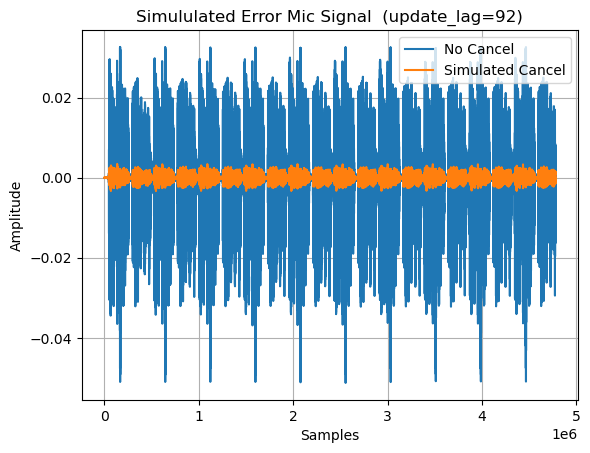

In [24]:
fx.reset()
fx.w = w_ls
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, 
    adapt=False, clean_feedback=False, plot=True, mu=0.0
)

In [3]:
data = np.load("./data/offline_package.npz")
new_irs = np.load("./data/current_irs.npz")
new_error_ir_raw = new_irs['error_ir']
new_ref_ir_raw = new_irs['ref_ir']

# Recordings
error = data["error"]
ref = data["ref"]
error_nc = data["error_nc"]
ref_nc = data["ref_nc"]
source = data["source"]

# IRs
error_ir = data["error_ir"]
ref_ir = data["ref_ir"]
error_ir_raw = data["error_ir_raw"]
ref_ir_raw = data["ref_ir_raw"]

# Learned controller
learned_weights = data["learned_weights"]
w_norm_log = data["w_norm_log"]

# Experiment info
n_repeats = int(data["n_repeats"])
fs = float(data["fs"])
ir_len = int(data["ir_len"])
panel_to_err_cm = float(data["panel_to_err_cm"])

# FxLMS parameters
mu = float(data["mu"])
leak = float(data["leak"])
eps = float(data["eps"])
lag = int(data["lag"])
cancel_gain = float(data["cancel_gain"])
ref_threshold = float(data["ref_threshold"])
mavg_tau_ms = float(data["mavg_tau_ms"])
update_sign = float(data["update_sign"])

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, lfilter, correlate


def crop_ir(raw_ir, ir_len=256, pre_samples=13):
    raw_ir = np.asarray(raw_ir).reshape(-1)

    peak = np.argmax(np.abs(raw_ir))
    start = peak - pre_samples
    end = start + ir_len

    if start < 0 or end > len(raw_ir):
        raise ValueError("IR crop outside available data")

    return raw_ir[start:end].copy(), peak, start


new_error_ir, error_peak, error_start = crop_ir(
    new_error_ir_raw,
    ir_len=256,
    pre_samples=13,
)

new_ref_ir, ref_peak, ref_start = crop_ir(
    new_ref_ir_raw,
    ir_len=256,
    pre_samples=13,
)

print("error peak:", error_peak)
print("ref peak:", ref_peak)
print("peak difference:", error_peak - ref_peak)

error peak: 512834
ref peak: 513050
peak difference: -216


In [5]:
old = np.asarray(error_ir).reshape(-1)
new = np.asarray(new_error_ir).reshape(-1)

N = min(len(old), len(new))
old = old[:N]
new = new[:N]

corr_same = np.corrcoef(old, new)[0, 1]
corr_flip = np.corrcoef(old, -new)[0, 1]

alpha = np.dot(old, new) / np.dot(new, new)

print("corr(old, new): ", corr_same)
print("corr(old, -new):", corr_flip)
print("old ≈ alpha * new:", alpha)
print("magnitude ratio new/old:", 1 / abs(alpha))
print("ratio dB:", 20 * np.log10(1 / abs(alpha)))

corr(old, new):  -0.8646577272213197
corr(old, -new): 0.8646577272213197
old ≈ alpha * new: -0.5792088
magnitude ratio new/old: 1.7264931
ratio dB: 4.743297


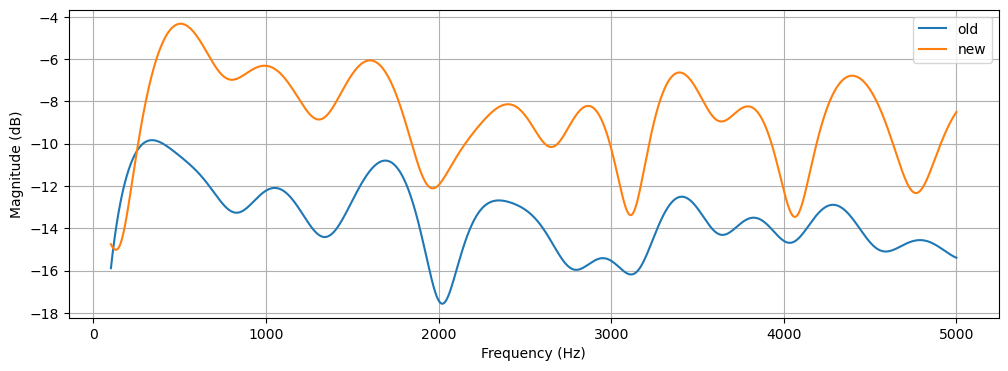

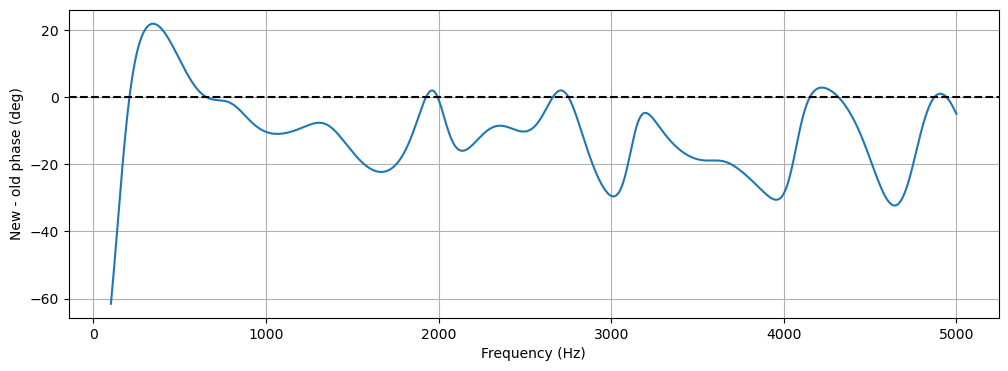

In [6]:
def compare_irs(old_ir, new_ir, fs=96_000, fmin=100, fmax=5000):
    nfft = 65536

    H_old = np.fft.rfft(old_ir, nfft)
    H_new = np.fft.rfft(new_ir, nfft)
    f = np.fft.rfftfreq(nfft, 1 / fs)

    mask = (f >= fmin) & (f <= fmax)

    # Best global sign for easier comparison only
    if np.corrcoef(old_ir, new_ir)[0, 1] < 0:
        H_new_display = -H_new
    else:
        H_new_display = H_new

    mag_old = 20 * np.log10(np.abs(H_old) + 1e-12)
    mag_new = 20 * np.log10(np.abs(H_new_display) + 1e-12)

    phase_diff = np.unwrap(
        np.angle(H_new_display / (H_old + 1e-20))
    ) * 180 / np.pi

    plt.figure(figsize=(12, 4))
    plt.plot(f[mask], mag_old[mask], label="old")
    plt.plot(f[mask], mag_new[mask], label="new")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(f[mask], phase_diff[mask])
    plt.axhline(0, color="k", linestyle="--")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("New - old phase (deg)")
    plt.grid()
    plt.show()


compare_irs(error_ir, new_error_ir)

In [7]:
def best_ir_shift(a, b, max_shift=100):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)

    results = []

    for shift in range(-max_shift, max_shift + 1):

        if shift >= 0:
            aa = a[shift:]
            bb = b[:len(aa)]
        else:
            bb = b[-shift:]
            aa = a[:len(bb)]

        alpha = np.dot(aa, bb) / (np.dot(bb, bb) + 1e-20)
        pred = alpha * bb

        rel_error = (
            np.linalg.norm(aa - pred) /
            (np.linalg.norm(aa) + 1e-20)
        )

        corr = np.corrcoef(aa, bb)[0, 1]

        results.append((shift, alpha, corr, rel_error))

    return min(results, key=lambda x: x[3]), results


best, results = best_ir_shift(error_ir, new_error_ir)

print("best shift:", best[0])
print("best scale:", best[1])
print("correlation:", best[2])
print("relative error:", best[3])

best shift: -1
best scale: -0.6010648
correlation: -0.8973774223118777
relative error: 0.44946203


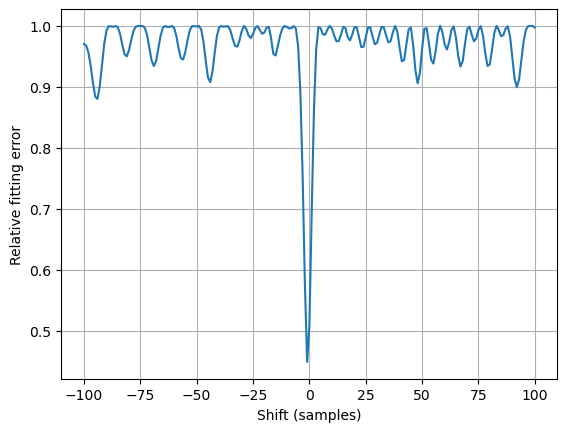

In [8]:
shifts = [r[0] for r in results]
errors = [r[3] for r in results]

plt.plot(shifts, errors)
plt.xlabel("Shift (samples)")
plt.ylabel("Relative fitting error")
plt.grid()
plt.show()

In [12]:
fx = OfflineFxLMS(
    M=len(learned_weights),
    error_ir=error_ir,
    ref_ir=ref_ir,
    fs=fs,
    nlms=True,
)

fx.set(
    mu=mu,
    leak=leak,
    eps=eps,
    lag=lag,
    cancel_gain=cancel_gain,
    ref_threshold=ref_threshold,
    mavg_tau_ms=mavg_tau_ms,
    update_sign=update_sign
)

In [10]:
def trim(n_iter, ref_arr=ref_nc, error_arr=error_nc, fs=fs):
    samples = int(n_iter * 5 * fs)
    return ref_arr[:samples], error_arr[:samples]

Simulated ANC / No ANC: -10.23 dB


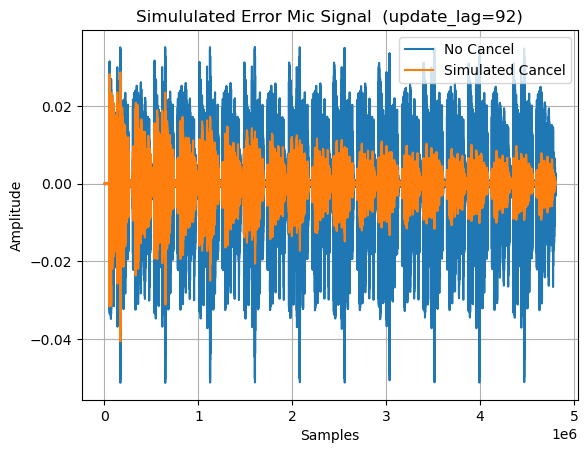

In [19]:
fx.reset()
fx.path_ir=error_ir
control, simulated_error, panel_output, weight_history = fx.process_array(
    *trim(10), 
    adapt=True, clean_feedback=True, plot=True,
    lag=92, mu=3e-3, leak=1e-7, system_lag=92,
    panel_ir=error_ir
)

Simulated ANC / No ANC: -11.76 dB


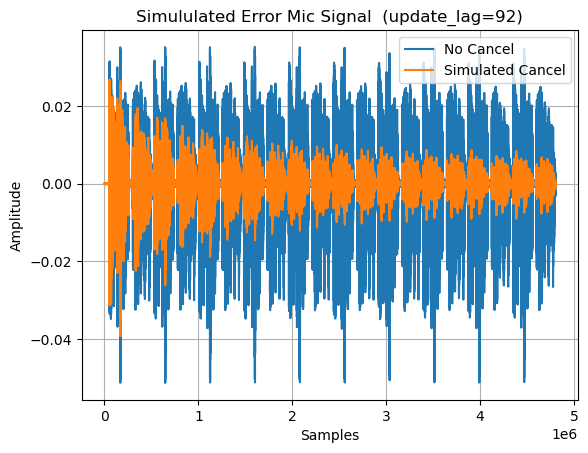

In [18]:
fx.reset()
fx.path_ir=error_ir
control, simulated_error, panel_output, weight_history = fx.process_array(
    *trim(10), 
    adapt=True, clean_feedback=True, plot=True,
    lag=92, mu=3e-3, leak=1e-7, system_lag=92,
    panel_ir=-new_error_ir
)

Simulated ANC / No ANC: -10.72 dB


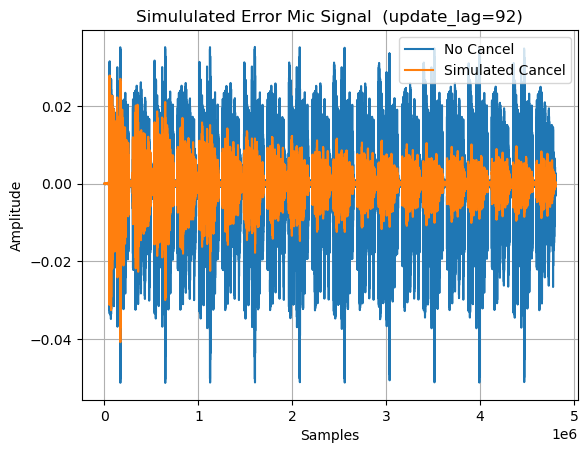

In [14]:
fx.reset()
fx.path_ir = new_error_ir
control, simulated_error, panel_output, weight_history = fx.process_array(
    *trim(10), 
    adapt=True, clean_feedback=True, plot=True,
    lag=92, mu=3e-3, leak=1e-7, system_lag=92,
    panel_ir=new_error_ir
)

Simulated ANC / No ANC: -9.36 dB


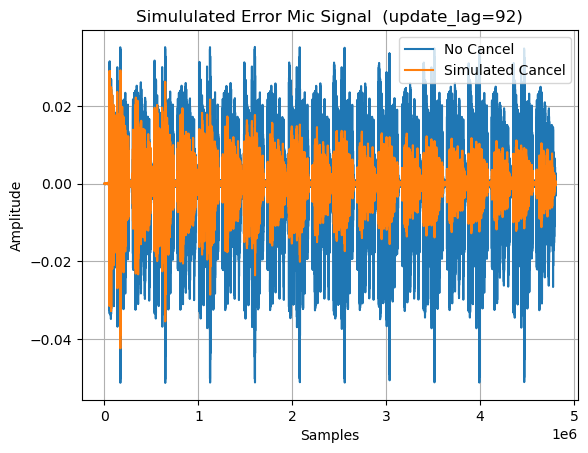

In [17]:
fx.reset()
fx.path_ir = -new_error_ir
control, simulated_error, panel_output, weight_history = fx.process_array(
    *trim(10), 
    adapt=True, clean_feedback=True, plot=True,
    lag=92, mu=3e-3, leak=1e-7, system_lag=92,
    panel_ir=error_ir
)

In [3]:
irs = np.load("./data/current_irs.npz")
error_ir_wrong, ref_ir_wrong = align_irs_by_distance(irs["error_ir"], irs["ref_ir"], distance_cm=4.5, ir_len=ir_len)


In [4]:
error_ir_shifted = np.concat([np.zeros_like(error_ir_wrong)[:30], error_ir_wrong[30:]])
ref_ir_shifted = np.concat([np.zeros_like(error_ir_wrong)[:30], error_ir_wrong[30:]])

In [5]:
def shift_ir(ir, n, ir_len):
    ir = np.asarray(ir)

    if n == 0:
        return ir[:ir_len].copy()

    if n > 0:
        return np.concatenate([
            np.zeros(n, dtype=ir.dtype),
            ir[:ir_len - n]
        ])

    k = -n
    return np.concatenate([
        ir[k:ir_len],
        np.zeros(k, dtype=ir.dtype)
    ])

In [6]:
fx = OfflineFxLMS(
    M=len(learned_weights),
    error_ir=error_ir,
    ref_ir=ref_ir,
    fs=fs,
    nlms=True,
)

fx.set(
    mu=mu,
    leak=leak,
    eps=eps,
    lag=lag,
    cancel_gain=cancel_gain,
    ref_threshold=ref_threshold,
    mavg_tau_ms=mavg_tau_ms,
    update_sign=update_sign
)


fx_wrong = OfflineFxLMS(
    M=len(learned_weights),
    error_ir=error_ir_wrong,
    ref_ir=ref_ir_wrong,
    fs=fs,
    nlms=True,
)

fx.set(
    mu=mu,
    leak=leak,
    eps=eps,
    lag=lag,
    cancel_gain=cancel_gain,
    ref_threshold=ref_threshold,
    mavg_tau_ms=mavg_tau_ms,
    update_sign=update_sign
)

In [14]:
fx_shifted = OfflineFxLMS(
    M=len(learned_weights),
    error_ir=error_ir_shifted,
    ref_ir=ref_ir,
    fs=fs,
    nlms=True,
)

fx.set(
    mu=mu,
    leak=leak,
    eps=eps,
    lag=lag,
    cancel_gain=cancel_gain,
    ref_threshold=ref_threshold,
    mavg_tau_ms=mavg_tau_ms,
    update_sign=update_sign
)

Simulated ANC / No ANC: -10.44 dB


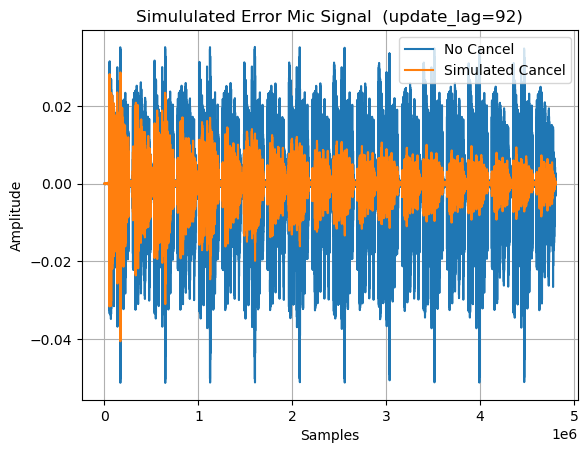

In [7]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    *trim(10), 
    adapt=True, clean_feedback=True, plot=True,
    lag=92, mu=3e-3, leak=0, system_lag=92
)

In [11]:
error_ir_long, ref_ir_long = align_irs_by_distance(error_ir, ref_ir, distance_cm=4.5, ir_len=1024, fs=fs)

shifts = list(range(-50, 50, 1))
db_redux = []
w_norms = []

ref_test, error_test = trim(5)
for shift in shifts:
    print('Shift:', shift)
    fx.path_ir = shift_ir(error_ir_long, shift, ir_len)

    fx.reset()
    control, simulated_error, panel_output, weight_history = fx.process_array(
        ref_test, error_test, plot=False,
        adapt=True, clean_feedback=True,
        lag=92, mu=1e-3, leak=1e-7, system_lag=92, 
        panel_ir=error_ir
    )

    db_redux.append(10 * np.log10(
        (np.mean(simulated_error**2) + 1e-20) /
        (np.mean(error_test**2) + 1e-20)
    ))

    w_norms.append(np.linalg.norm(fx.w))
    print()

print(db_redux)
print(w_norms)

Shift: -50
Simulated ANC / No ANC: 0.80 dB

Shift: -49
Simulated ANC / No ANC: -1.10 dB

Shift: -48
Simulated ANC / No ANC: -1.85 dB

Shift: -47
Simulated ANC / No ANC: -2.09 dB

Shift: -46
Simulated ANC / No ANC: -2.00 dB

Shift: -45
Simulated ANC / No ANC: -1.65 dB

Shift: -44
Simulated ANC / No ANC: -1.02 dB

Shift: -43
Simulated ANC / No ANC: -0.27 dB

Shift: -42
Simulated ANC / No ANC: 0.28 dB

Shift: -41
Simulated ANC / No ANC: 0.49 dB

Shift: -40
Simulated ANC / No ANC: 0.17 dB

Shift: -39
Simulated ANC / No ANC: -0.54 dB

Shift: -38
Simulated ANC / No ANC: -1.12 dB

Shift: -37
Simulated ANC / No ANC: -1.44 dB

Shift: -36
Simulated ANC / No ANC: -1.71 dB

Shift: -35
Simulated ANC / No ANC: -1.92 dB

Shift: -34
Simulated ANC / No ANC: -2.04 dB

Shift: -33
Simulated ANC / No ANC: -2.12 dB

Shift: -32
Simulated ANC / No ANC: -2.10 dB

Shift: -31
Simulated ANC / No ANC: -1.94 dB

Shift: -30
Simulated ANC / No ANC: -1.83 dB

Shift: -29
Simulated ANC / No ANC: -2.02 dB

Shift: -28
Sim

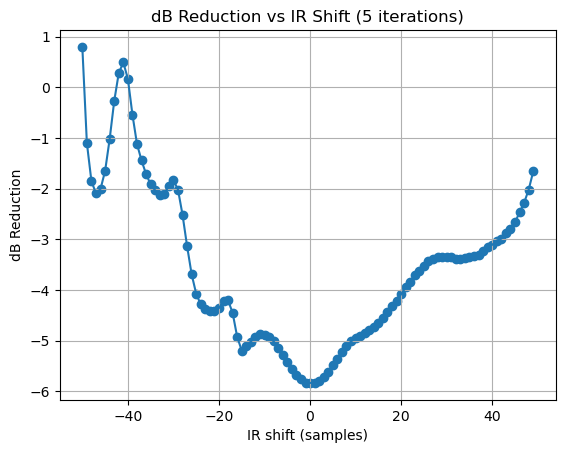

In [12]:
plt.plot(shifts, db_redux)
plt.scatter(shifts, db_redux)

plt.title(f"dB Reduction vs IR Shift (5 iterations)")
plt.xlabel("IR shift (samples)")
plt.ylabel("dB Reduction")
plt.grid(True)
plt.show()

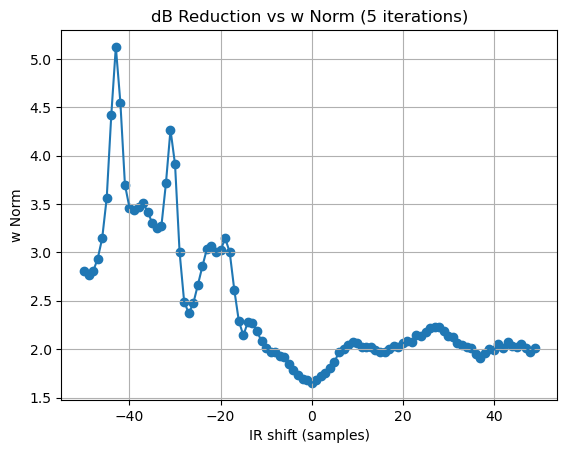

In [13]:
plt.plot(shifts, w_norms)
plt.scatter(shifts, w_norms)

plt.title(f"dB Reduction vs w Norm (5 iterations)")
plt.xlabel("IR shift (samples)")
plt.ylabel("w Norm")
plt.grid(True)
plt.show()

Simulated ANC / No ANC: -10.72 dB


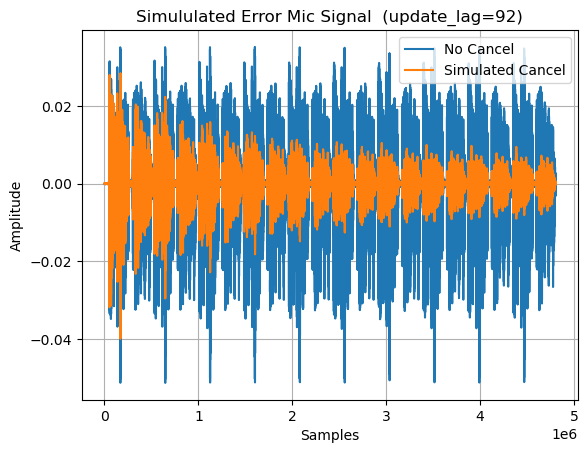

In [14]:
fx.reset()
fx.path_ir = error_ir_wrong
control, simulated_error, panel_output, weight_history = fx.process_array(
    *trim(10), 
    adapt=True, clean_feedback=False, plot=True,
    lag=92, mu=3e-3, leak=1e-7, system_lag=92, panel_ir=error_ir
)

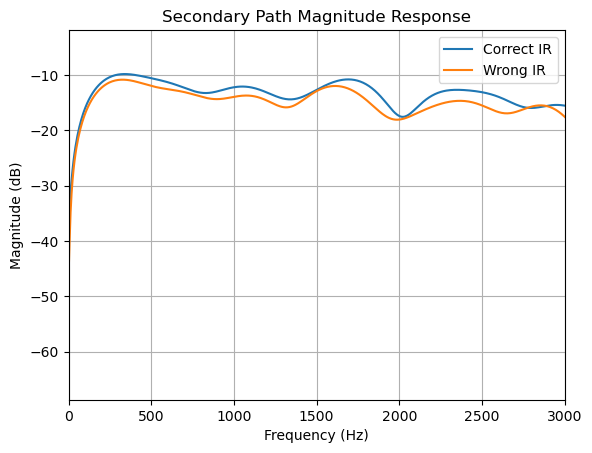

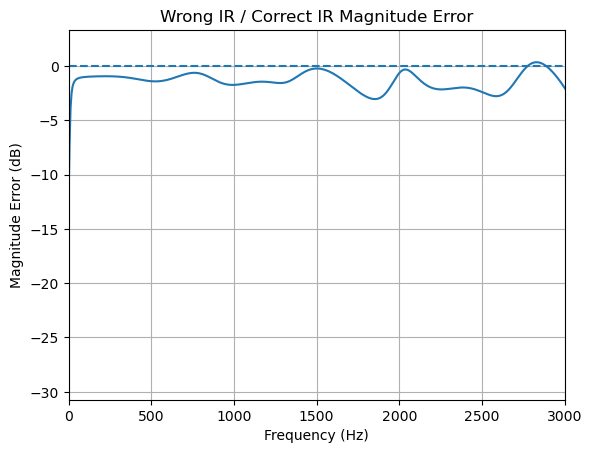

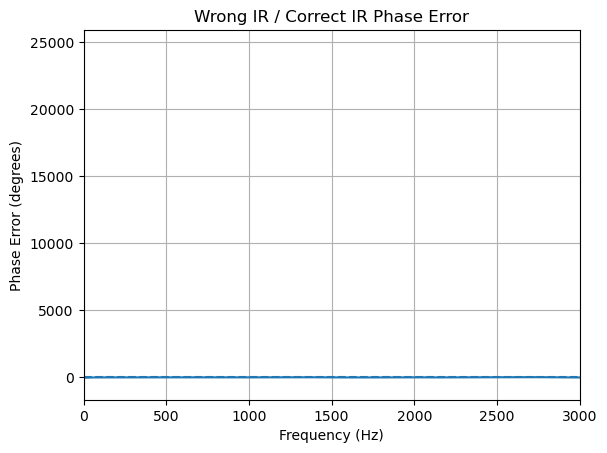

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we're comparing the same length
N = min(len(error_ir), len(error_ir_wrong))
h_true = np.asarray(error_ir[:N], dtype=np.float64)
h_wrong = np.asarray(error_ir_wrong[:N], dtype=np.float64)

# Zero-pad for smoother frequency-domain plots
nfft = 16384

H_true = np.fft.rfft(h_true, n=nfft)
H_wrong = np.fft.rfft(h_wrong, n=nfft)
freqs = np.fft.rfftfreq(nfft, d=1/fs)

eps = 1e-12

# Individual magnitude responses
mag_true = 20 * np.log10(np.abs(H_true) + eps)
mag_wrong = 20 * np.log10(np.abs(H_wrong) + eps)

# Wrong relative to correct
ratio = H_wrong / (H_true + eps)

mag_error_db = 20 * np.log10(np.abs(ratio) + eps)

# Unwrapped relative phase is what we're most interested in
phase_error_deg = np.unwrap(np.angle(ratio)) * 180 / np.pi


# ---------------------------------------------------------
# Magnitude responses
# ---------------------------------------------------------

plt.figure()

plt.plot(freqs, mag_true, label="Correct IR")
plt.plot(freqs, mag_wrong, label="Wrong IR")

plt.xlim(0, 3000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Secondary Path Magnitude Response")
plt.grid(True)
plt.legend()
plt.show()


# ---------------------------------------------------------
# Magnitude mismatch
# ---------------------------------------------------------

plt.figure()

plt.plot(freqs, mag_error_db)

plt.axhline(0, linestyle="--")

plt.xlim(0, 3000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude Error (dB)")
plt.title("Wrong IR / Correct IR Magnitude Error")
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# Phase mismatch
# ---------------------------------------------------------

plt.figure()

plt.plot(freqs, phase_error_deg)

plt.axhline(0, linestyle="--")

plt.xlim(0, 3000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Error (degrees)")
plt.title("Wrong IR / Correct IR Phase Error")
plt.grid(True)
plt.show()

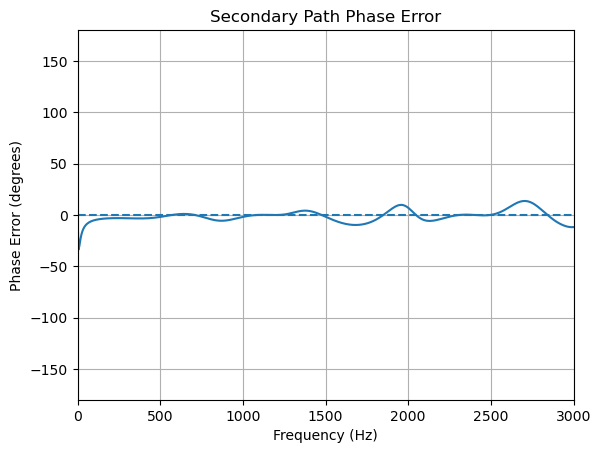

In [16]:
phase_error_wrapped_deg = np.angle(ratio, deg=True)

plt.figure()

plt.plot(freqs, phase_error_wrapped_deg)

plt.axhline(0, linestyle="--")

plt.xlim(0, 3000)
plt.ylim(-180, 180)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Error (degrees)")
plt.title("Secondary Path Phase Error")
plt.grid(True)
plt.show()

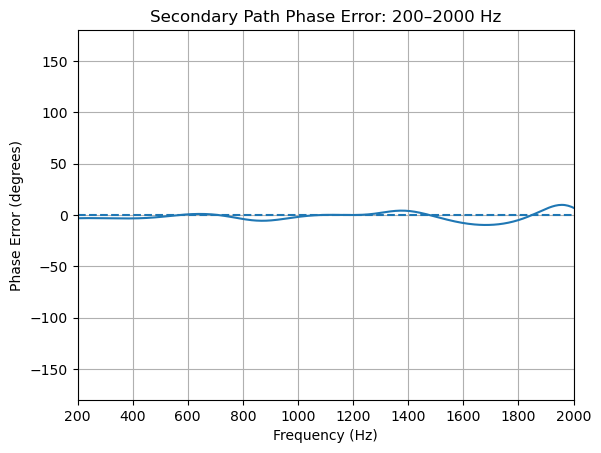

In [17]:
plt.figure()

plt.plot(freqs, phase_error_wrapped_deg)

plt.axhline(0, linestyle="--")

plt.xlim(200, 2000)
plt.ylim(-180, 180)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Error (degrees)")
plt.title("Secondary Path Phase Error: 200–2000 Hz")
plt.grid(True)
plt.show()

Simulated ANC / No ANC: -1.50 dB
Simulated ANC / No ANC: -2.41 dB
Simulated ANC / No ANC: -3.19 dB
Simulated ANC / No ANC: -3.85 dB
Simulated ANC / No ANC: -4.33 dB
Simulated ANC / No ANC: -4.66 dB
Simulated ANC / No ANC: -4.90 dB
Simulated ANC / No ANC: -5.06 dB
Simulated ANC / No ANC: -5.13 dB
Simulated ANC / No ANC: -5.11 dB
Simulated ANC / No ANC: -5.09 dB
Simulated ANC / No ANC: -5.20 dB
Simulated ANC / No ANC: -5.50 dB
Simulated ANC / No ANC: -5.90 dB
Simulated ANC / No ANC: -6.35 dB
Simulated ANC / No ANC: -6.93 dB
Simulated ANC / No ANC: -7.44 dB
Simulated ANC / No ANC: -7.77 dB
Simulated ANC / No ANC: -7.98 dB
Simulated ANC / No ANC: -8.09 dB
Simulated ANC / No ANC: -8.12 dB
Simulated ANC / No ANC: -8.08 dB
Simulated ANC / No ANC: -7.96 dB
Simulated ANC / No ANC: -7.75 dB
Simulated ANC / No ANC: -7.42 dB
Simulated ANC / No ANC: -6.92 dB
Simulated ANC / No ANC: -6.31 dB
Simulated ANC / No ANC: -5.82 dB
Simulated ANC / No ANC: -5.42 dB
Simulated ANC / No ANC: -5.13 dB
Simulated 

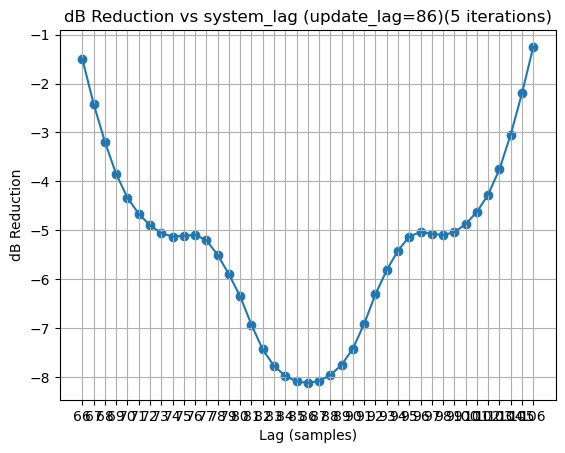

In [13]:
update_lag = 86
bound = 20

system_lags = list(range(update_lag - bound, update_lag + bound + 1, 1))
db_redux_86_5 = []

ref_test, error_test = trim(5)

for lag in system_lags:
    fx.reset()
    control, simulated_error, panel_output, weight_history = fx.process_array(
        ref_test, error_test,
        adapt=True, clean_feedback=False, plot=False,
        lag=update_lag, mu=3e-3, leak=3e-7, system_lag=lag
    )

    db_redux_86_5.append(10 * np.log10(
        (np.mean(simulated_error**2) + 1e-20) /
        (np.mean(error_test**2) + 1e-20)
    ))


plt.plot(system_lags, db_redux_86_5)
plt.scatter(system_lags, db_redux_86_5)

plt.title(f"dB Reduction vs system_lag (update_lag={update_lag})(5 iterations)")
plt.xlabel("Lag (samples)")
plt.ylabel("dB Reduction")
plt.grid(True)
plt.xticks(system_lags)
plt.show()

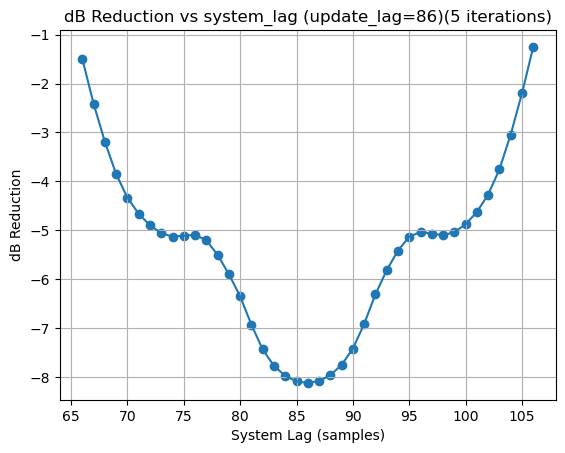

In [19]:
plt.plot(system_lags, db_redux_86_5)
plt.scatter(system_lags, db_redux_86_5)

plt.title(f"dB Reduction vs system_lag (update_lag={update_lag})(5 iterations)")
plt.xlabel("System Lag (samples)")
plt.ylabel("dB Reduction")
plt.grid(True)
plt.show()

Simulated ANC / No ANC: -1.65 dB
Simulated ANC / No ANC: -2.54 dB
Simulated ANC / No ANC: -3.30 dB
Simulated ANC / No ANC: -3.95 dB
Simulated ANC / No ANC: -4.43 dB
Simulated ANC / No ANC: -4.75 dB
Simulated ANC / No ANC: -4.98 dB
Simulated ANC / No ANC: -5.13 dB
Simulated ANC / No ANC: -5.19 dB
Simulated ANC / No ANC: -5.16 dB
Simulated ANC / No ANC: -5.11 dB
Simulated ANC / No ANC: -5.19 dB
Simulated ANC / No ANC: -5.48 dB
Simulated ANC / No ANC: -5.90 dB
Simulated ANC / No ANC: -6.38 dB
Simulated ANC / No ANC: -6.97 dB
Simulated ANC / No ANC: -7.48 dB
Simulated ANC / No ANC: -7.82 dB
Simulated ANC / No ANC: -8.03 dB
Simulated ANC / No ANC: -8.14 dB
Simulated ANC / No ANC: -8.18 dB
Simulated ANC / No ANC: -8.14 dB
Simulated ANC / No ANC: -8.02 dB
Simulated ANC / No ANC: -7.80 dB
Simulated ANC / No ANC: -7.47 dB
Simulated ANC / No ANC: -6.97 dB
Simulated ANC / No ANC: -6.37 dB
Simulated ANC / No ANC: -5.87 dB
Simulated ANC / No ANC: -5.46 dB
Simulated ANC / No ANC: -5.18 dB
Simulated 

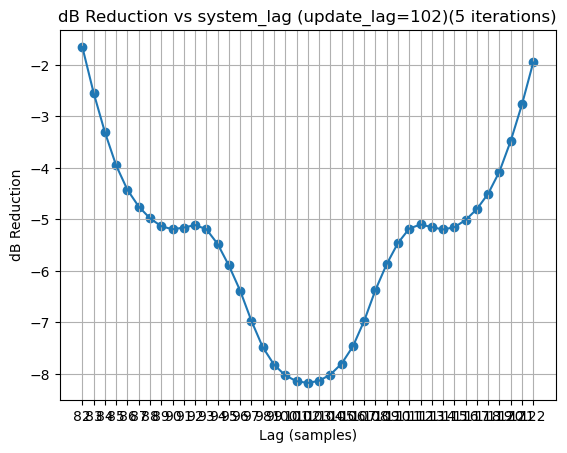

In [14]:
update_lag = 102
bound = 20

system_lags = list(range(update_lag - bound, update_lag + bound + 1, 1))
db_redux_102_5 = []

ref_test, error_test = trim(5)

for lag in system_lags:
    fx.reset()
    control, simulated_error, panel_output, weight_history = fx.process_array(
        ref_test, error_test,
        adapt=True, clean_feedback=False, plot=False,
        lag=update_lag, mu=3e-3, leak=3e-7, system_lag=lag
    )

    db_redux_102_5.append(10 * np.log10(
        (np.mean(simulated_error**2) + 1e-20) /
        (np.mean(error_test**2) + 1e-20)
    ))


plt.plot(system_lags, db_redux_102_5)
plt.scatter(system_lags, db_redux_102_5)

plt.title(f"dB Reduction vs system_lag (update_lag={update_lag})(5 iterations)")
plt.xlabel("Lag (samples)")
plt.ylabel("dB Reduction")
plt.grid(True)
plt.show()

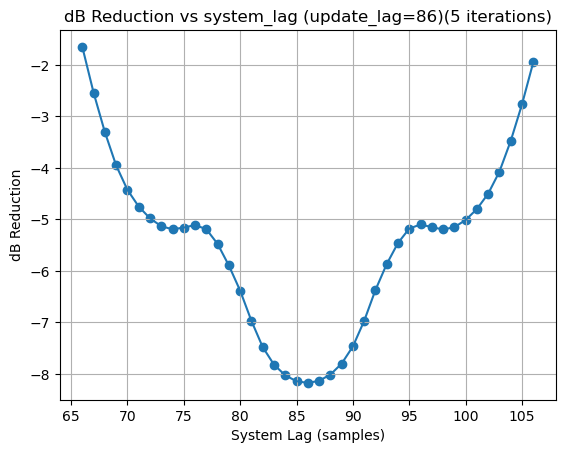

In [20]:
plt.plot(system_lags, db_redux_102_5)
plt.scatter(system_lags, db_redux_102_5)

plt.title(f"dB Reduction vs system_lag (update_lag={update_lag})(5 iterations)")
plt.xlabel("System Lag (samples)")
plt.ylabel("dB Reduction")
plt.grid(True)
plt.show()

Simulated ANC / No ANC: -1.00 dB
Simulated ANC / No ANC: -2.00 dB
Simulated ANC / No ANC: -2.89 dB
Simulated ANC / No ANC: -3.63 dB
Simulated ANC / No ANC: -4.17 dB
Simulated ANC / No ANC: -4.54 dB
Simulated ANC / No ANC: -4.80 dB
Simulated ANC / No ANC: -4.98 dB
Simulated ANC / No ANC: -5.06 dB
Simulated ANC / No ANC: -5.04 dB
Simulated ANC / No ANC: -5.02 dB
Simulated ANC / No ANC: -5.13 dB
Simulated ANC / No ANC: -5.42 dB
Simulated ANC / No ANC: -5.81 dB
Simulated ANC / No ANC: -6.29 dB
Simulated ANC / No ANC: -6.90 dB
Simulated ANC / No ANC: -7.40 dB
Simulated ANC / No ANC: -7.74 dB
Simulated ANC / No ANC: -7.95 dB
Simulated ANC / No ANC: -8.08 dB
Simulated ANC / No ANC: -8.12 dB
Simulated ANC / No ANC: -8.09 dB
Simulated ANC / No ANC: -7.99 dB
Simulated ANC / No ANC: -7.79 dB
Simulated ANC / No ANC: -7.45 dB
Simulated ANC / No ANC: -6.94 dB
Simulated ANC / No ANC: -6.34 dB
Simulated ANC / No ANC: -5.86 dB
Simulated ANC / No ANC: -5.47 dB
Simulated ANC / No ANC: -5.19 dB
Simulated 

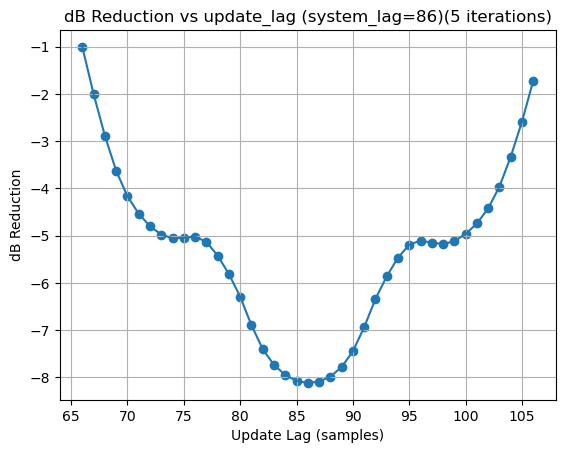

In [21]:
system_lag = 86
bound = 20

update_lags = list(range(system_lag - bound, system_lag + bound + 1, 1))
db_redux_86 = []

ref_test, error_test = trim(5)

for lag in update_lags:
    fx.reset()
    control, simulated_error, panel_output, weight_history = fx.process_array(
        ref_test, error_test,
        adapt=True, clean_feedback=False, plot=False,
        lag=lag, mu=3e-3, leak=3e-7, system_lag=system_lag
    )

    db_redux_86.append(10 * np.log10(
        (np.mean(simulated_error**2) + 1e-20) /
        (np.mean(error_test**2) + 1e-20)
    ))


plt.plot(system_lags, db_redux_86)
plt.scatter(system_lags, db_redux_86)

plt.title(f"dB Reduction vs update_lag (system_lag={system_lag})(5 iterations)")
plt.xlabel("Update Lag (samples)")
plt.ylabel("dB Reduction")
plt.grid(True)
plt.show()

Simulated ANC / No ANC: -1.15 dB
Simulated ANC / No ANC: -2.11 dB
Simulated ANC / No ANC: -2.99 dB
Simulated ANC / No ANC: -3.74 dB
Simulated ANC / No ANC: -4.27 dB
Simulated ANC / No ANC: -4.63 dB
Simulated ANC / No ANC: -4.89 dB
Simulated ANC / No ANC: -5.06 dB
Simulated ANC / No ANC: -5.12 dB
Simulated ANC / No ANC: -5.09 dB
Simulated ANC / No ANC: -5.05 dB
Simulated ANC / No ANC: -5.14 dB
Simulated ANC / No ANC: -5.42 dB
Simulated ANC / No ANC: -5.82 dB
Simulated ANC / No ANC: -6.34 dB
Simulated ANC / No ANC: -6.96 dB
Simulated ANC / No ANC: -7.47 dB
Simulated ANC / No ANC: -7.80 dB
Simulated ANC / No ANC: -8.02 dB
Simulated ANC / No ANC: -8.14 dB
Simulated ANC / No ANC: -8.18 dB
Simulated ANC / No ANC: -8.14 dB
Simulated ANC / No ANC: -8.03 dB
Simulated ANC / No ANC: -7.82 dB
Simulated ANC / No ANC: -7.47 dB
Simulated ANC / No ANC: -6.97 dB
Simulated ANC / No ANC: -6.39 dB
Simulated ANC / No ANC: -5.90 dB
Simulated ANC / No ANC: -5.48 dB
Simulated ANC / No ANC: -5.20 dB
Simulated 

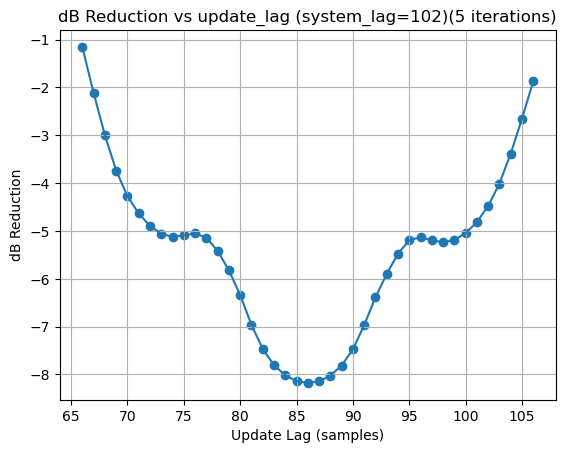

In [22]:
system_lag = 102
bound = 20

update_lags = list(range(system_lag - bound, system_lag + bound + 1, 1))
db_redux_102 = []

ref_test, error_test = trim(5)

for lag in update_lags:
    fx.reset()
    control, simulated_error, panel_output, weight_history = fx.process_array(
        ref_test, error_test,
        adapt=True, clean_feedback=False, plot=False,
        lag=lag, mu=3e-3, leak=3e-7, system_lag=system_lag
    )

    db_redux_102.append(10 * np.log10(
        (np.mean(simulated_error**2) + 1e-20) /
        (np.mean(error_test**2) + 1e-20)
    ))


plt.plot(system_lags, db_redux_102)
plt.scatter(system_lags, db_redux_102)

plt.title(f"dB Reduction vs update_lag (system_lag={system_lag})(5 iterations)")
plt.xlabel("Update Lag (samples)")
plt.ylabel("dB Reduction")
plt.grid(True)
plt.show()

In [5]:
fx.adapt = True
fx.lag = 86
fx.mu = fx.dtype(1e-4)
fx.leak = fx.dtype(0.0)
fx.reset()

for n in range(96001):
    control_n, cleaned_ref_n = fx.compute_control(ref_nc[n])

    old_debug = getattr(fx, "debug_xf", None)

    fx.process(cleaned_ref_n, error_nc[n])

    if hasattr(fx, "debug_xf") and fx.debug_xf is not old_debug:
        debug_n = n
        actual = fx.debug_xf.copy()

print("actual update occurred at n =", debug_n)

actual update occurred at n = 96000


In [6]:
fx.xf.shape

(2220,)

In [7]:
from scipy.signal import lfilter

xf_direct = lfilter(
    np.asarray(error_ir, dtype=np.float64),
    [1.0],
    np.asarray(ref_nc, dtype=np.float64)
)

In [8]:
expected = np.array([
    xf_direct[debug_n - fx.lag - k]
    for k in range(fx.M)
])

In [9]:
diff = actual.astype(np.float64) - expected

print("sample:", debug_n)
print("lag:", fx.lag)

print("max absolute difference:",
      np.max(np.abs(diff)))

print("RMS difference:",
      np.sqrt(np.mean(diff**2)))

print("relative error:",
      np.linalg.norm(diff) /
      (np.linalg.norm(expected) + 1e-20))

print("correlation:",
      np.corrcoef(actual, expected)[0, 1])

sample: 96000
lag: 86
max absolute difference: 7.284839814714061e-10
RMS difference: 1.8183003771880966e-10
relative error: 4.48572779555226e-08
correlation: 0.9999999999999989


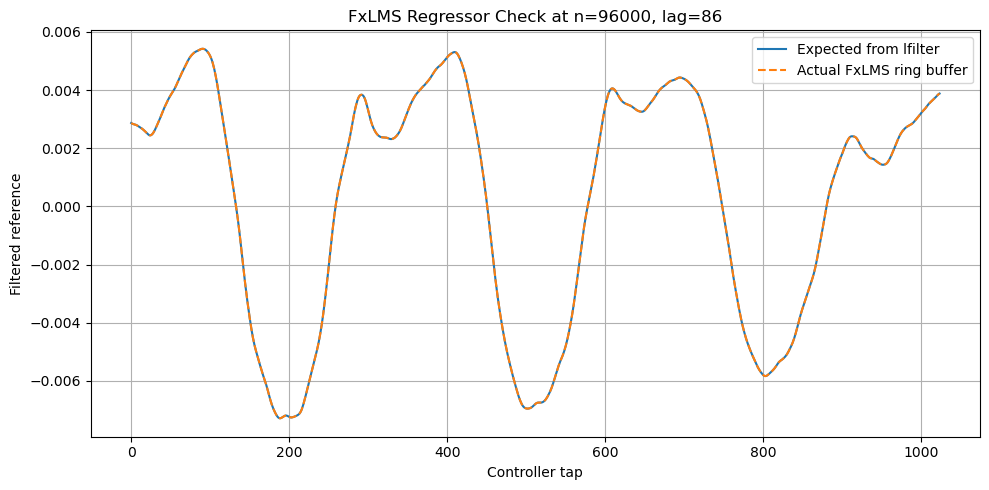

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(expected, label="Expected from lfilter")
plt.plot(actual, "--", label="Actual FxLMS ring buffer")

plt.xlabel("Controller tap")
plt.ylabel("Filtered reference")
plt.title(
    f"FxLMS Regressor Check at n={debug_n}, lag={fx.lag}"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
for offset in range(-5, 6):

    expected_offset = np.array([
        xf_direct[debug_n - fx.lag + offset - k]
        for k in range(fx.M)
    ])

    corr = np.corrcoef(actual, expected_offset)[0, 1]

    print(f"offset {offset:+d}: corr = {corr:.8f}")

offset -5: corr = 0.99239068
offset -4: corr = 0.99511818
offset -3: corr = 0.99724848
offset -2: corr = 0.99877523
offset -1: corr = 0.99969350
offset +0: corr = 1.00000000
offset +1: corr = 0.99969336
offset +2: corr = 0.99877412
offset +3: corr = 0.99724466
offset +4: corr = 0.99510891
offset +5: corr = 0.99237209


In [12]:
print("x_head:", fx.x_head)
print("update_head:", fx.debug_update_head)
print("M:", fx.M)
print("first-copy samples available:",
      fx.M - fx.debug_update_head)

x_head: 255
update_head: 341
M: 1024
first-copy samples available: 683


In [13]:
M = fx.M

dup_diff = (
    fx.xf[:M].astype(np.float64)
    - fx.xf[M:2*M].astype(np.float64)
)

print("duplicate max error:",
      np.max(np.abs(dup_diff)))

print("duplicate RMS error:",
      np.sqrt(np.mean(dup_diff**2)))

bad = np.where(np.abs(dup_diff) > 1e-8)[0]

print("number mismatched:", len(bad))

if len(bad):
    print("first mismatches:", bad[:20])

duplicate max error: 0.0
duplicate RMS error: 0.0
number mismatched: 0


In [14]:
boundary = fx.M - fx.debug_update_head

print("boundary:", boundary)

for k in range(boundary - 5, boundary + 6):
    print(
        f"k={k:4d}  "
        f"actual={actual[k]: .8f}  "
        f"expected={expected[k]: .8f}  "
        f"diff={actual[k]-expected[k]: .8f}"
    )

boundary: 683
k= 678  actual= 0.00421924  expected= 0.00421924  diff= 0.00000000
k= 679  actual= 0.00424421  expected= 0.00424422  diff=-0.00000000
k= 680  actual= 0.00426766  expected= 0.00426766  diff=-0.00000000
k= 681  actual= 0.00428787  expected= 0.00428787  diff= 0.00000000
k= 682  actual= 0.00430408  expected= 0.00430408  diff= 0.00000000
k= 683  actual= 0.00431644  expected= 0.00431644  diff=-0.00000000
k= 684  actual= 0.00432596  expected= 0.00432596  diff= 0.00000000
k= 685  actual= 0.00433397  expected= 0.00433397  diff= 0.00000000
k= 686  actual= 0.00434156  expected= 0.00434156  diff=-0.00000000
k= 687  actual= 0.00435000  expected= 0.00435000  diff= 0.00000000
k= 688  actual= 0.00436034  expected= 0.00436034  diff=-0.00000000


In [15]:
print("\nIndices used around boundary:")

for k in range(boundary - 5, boundary + 6):
    idx = fx.debug_update_head + k
    print(
        f"k={k:4d}  "
        f"xf index={idx:4d}  "
        f"value={fx.xf[idx]: .8f}"
    )


Indices used around boundary:
k= 678  xf index=1019  value= 0.00421924
k= 679  xf index=1020  value= 0.00424421
k= 680  xf index=1021  value= 0.00426766
k= 681  xf index=1022  value= 0.00428787
k= 682  xf index=1023  value= 0.00430408
k= 683  xf index=1024  value= 0.00431644
k= 684  xf index=1025  value= 0.00432596
k= 685  xf index=1026  value= 0.00433397
k= 686  xf index=1027  value= 0.00434156
k= 687  xf index=1028  value= 0.00435000
k= 688  xf index=1029  value= 0.00436034


In [14]:
lags = list(range(0, 121, 10))
db_redux = []

for lag in lags:
    fx.reset()
    control, simulated_error, panel_output, weight_history = fx.process_array(
        *trim(5), 
        adapt=True, clean_feedback=False, save_weight_every_s=5, plot=False,
        lag=lag, mu=1e-3, leak=3e-6
    )

    db_redux.append(10 * np.log10(
        (np.mean(simulated_error**2) + 1e-20) /
        (np.mean(error_nc**2) + 1e-20)
    ))

Simulated ANC / No ANC: -4.63 dB
Simulated ANC / No ANC: -4.64 dB
Simulated ANC / No ANC: -4.63 dB
Simulated ANC / No ANC: -4.63 dB
Simulated ANC / No ANC: -4.62 dB
Simulated ANC / No ANC: -4.56 dB
Simulated ANC / No ANC: -4.47 dB
Simulated ANC / No ANC: -4.36 dB
Simulated ANC / No ANC: -4.31 dB
Simulated ANC / No ANC: -4.32 dB
Simulated ANC / No ANC: -4.34 dB
Simulated ANC / No ANC: -4.34 dB
Simulated ANC / No ANC: -4.25 dB


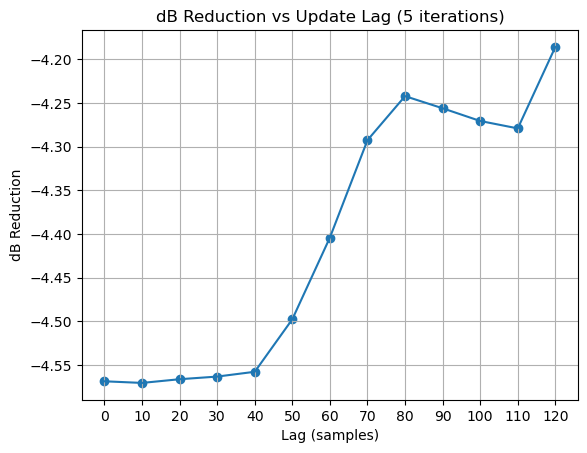

In [15]:
plt.plot(lags, db_redux)
plt.scatter(lags, db_redux)

plt.title("dB Reduction vs Update Lag (5 iterations)")
plt.xlabel("Lag (samples)")
plt.ylabel("dB Reduction")
plt.grid(True)
plt.xticks(lags)
plt.show()

Simulated ANC / No ANC: -12.62 dB


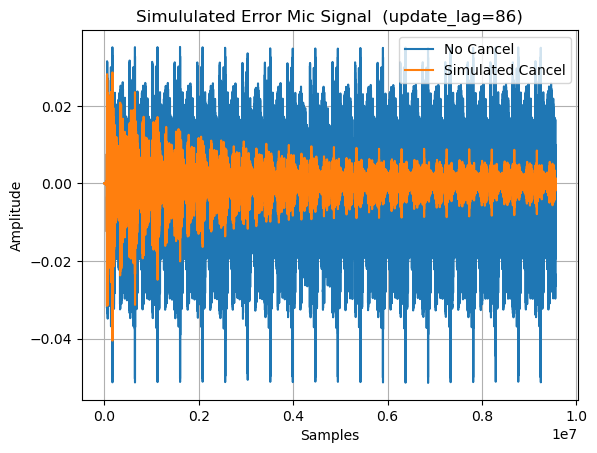

In [6]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, 
    adapt=True, clean_feedback=False, save_weight_every_s=5, plot=True,
    lag=86, mu=3e-3, leak=0
)

Simulated ANC / No ANC: -9.58 dB


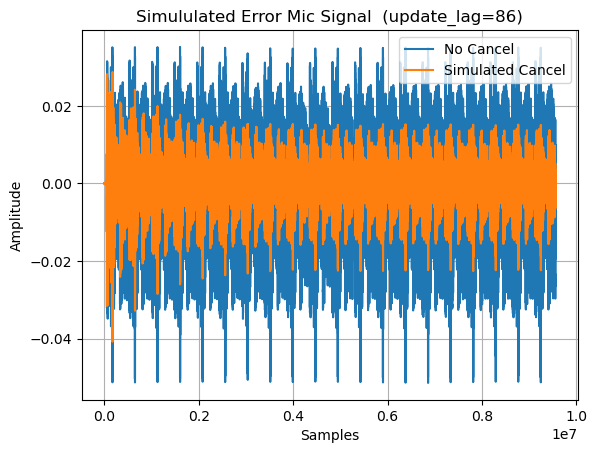

In [5]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, 
    adapt=True, clean_feedback=False, save_weight_every_s=5, plot=True,
    lag=86, mu=3e-3, leak=1e-6
)

Simulated ANC / No ANC: -9.62 dB


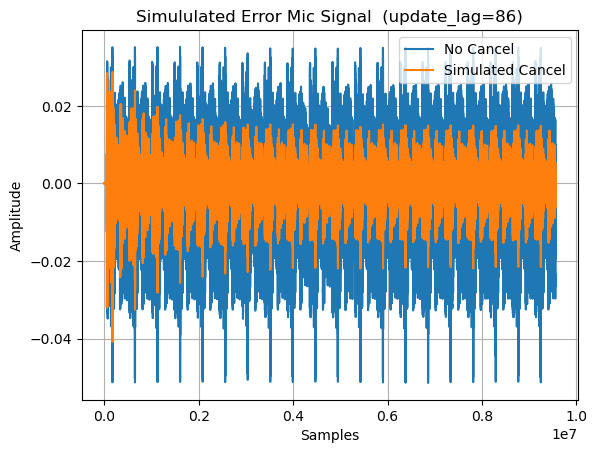

In [16]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, 
    adapt=True, clean_feedback=False, save_weight_every_s=5, plot=True,
    lag=86, mu=3e-3, leak=1e-6
)

In [5]:
lags = list(range(0, 121, 10))
db_redux = []

for lag in lags:
    fx.reset()
    control, simulated_error, panel_output, weight_history = fx.process_array(
        *trim(5), 
        adapt=True, clean_feedback=False, save_weight_every_s=5, plot=False,
        lag=lag, mu=1e-3, leak=3e-6
    )

    db_redux.append(10 * np.log10(
        (np.mean(simulated_error**2) + 1e-20) /
        (np.mean(error_nc**2) + 1e-20)
    ))

Simulated ANC / No ANC: -4.64 dB
Simulated ANC / No ANC: -4.62 dB
Simulated ANC / No ANC: -4.58 dB
Simulated ANC / No ANC: -4.51 dB
Simulated ANC / No ANC: -4.42 dB
Simulated ANC / No ANC: -4.13 dB
Simulated ANC / No ANC: -3.77 dB
Simulated ANC / No ANC: -3.35 dB
Simulated ANC / No ANC: -3.10 dB
Simulated ANC / No ANC: -3.16 dB
Simulated ANC / No ANC: -3.27 dB
Simulated ANC / No ANC: -3.24 dB
Simulated ANC / No ANC: -2.84 dB


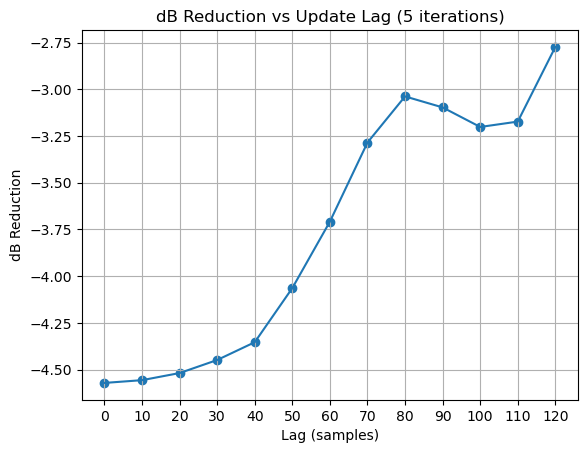

In [6]:
plt.plot(lags, db_redux)
plt.scatter(lags, db_redux)

plt.title("dB Reduction vs Update Lag (5 iterations)")
plt.xlabel("Lag (samples)")
plt.ylabel("dB Reduction")
plt.grid(True)
plt.xticks(lags)
plt.show()

In [16]:
lags = list(range(0, 121, 10))
db_redux = []

for lag in lags:
    fx.reset()
    control, simulated_error, panel_output, weight_history = fx.process_array(
        *trim(5), 
        adapt=True, clean_feedback=False, save_weight_every_s=5, plot=False,
        lag=lag, mu=3e-4, leak=1e-6
    )

    db_redux.append(10 * np.log10(
        (np.mean(simulated_error**2) + 1e-20) /
        (np.mean(error_nc**2) + 1e-20)
    ))

Simulated ANC / No ANC: -3.47 dB
Simulated ANC / No ANC: -3.45 dB
Simulated ANC / No ANC: -3.40 dB
Simulated ANC / No ANC: -3.34 dB
Simulated ANC / No ANC: -3.26 dB
Simulated ANC / No ANC: -3.11 dB
Simulated ANC / No ANC: -2.95 dB
Simulated ANC / No ANC: -2.81 dB
Simulated ANC / No ANC: -2.78 dB
Simulated ANC / No ANC: -2.82 dB
Simulated ANC / No ANC: -2.81 dB
Simulated ANC / No ANC: -2.69 dB
Simulated ANC / No ANC: -2.32 dB


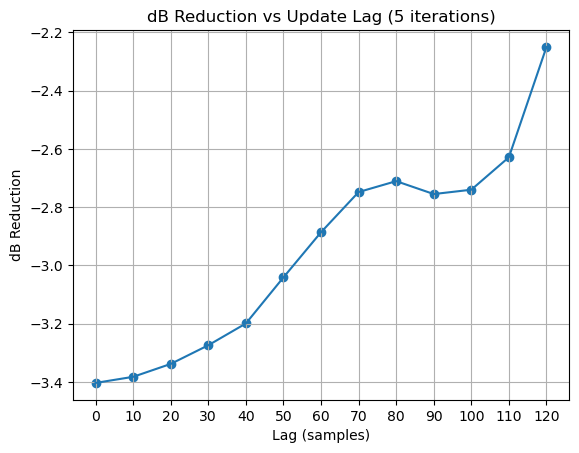

In [17]:
plt.plot(lags, db_redux)
plt.scatter(lags, db_redux)

plt.title("dB Reduction vs Update Lag (5 iterations)")
plt.xlabel("Lag (samples)")
plt.ylabel("dB Reduction")
plt.grid(True)
plt.xticks(lags)
plt.show()

Simulated ANC / No ANC: -3.07 dB


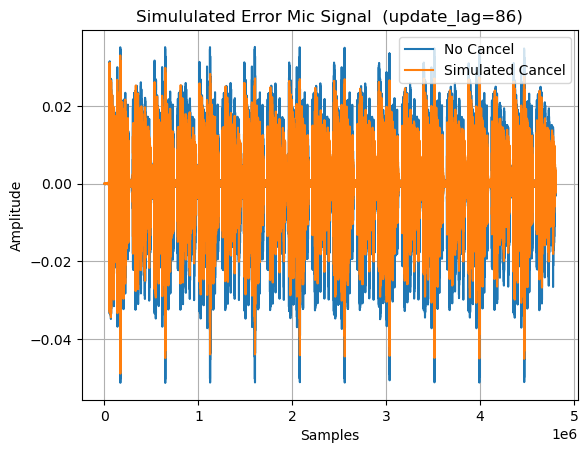

In [15]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    *trim(10), 
    adapt=True, clean_feedback=False, save_weight_every_s=5, plot=True,
    lag=86, mu=3e-4, leak=1e-6
)

Simulated ANC / No ANC: -1.98 dB


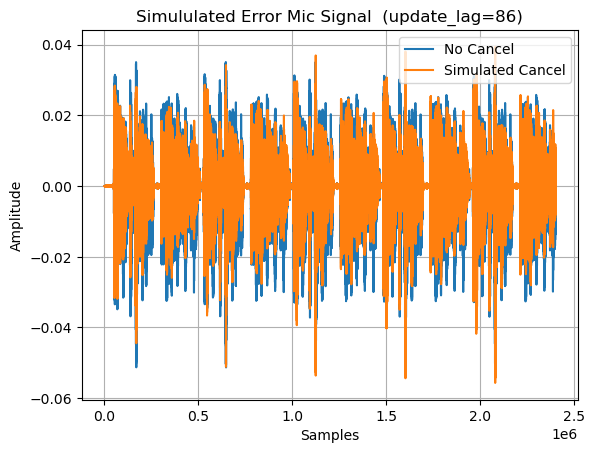

In [ ]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    *trim(5), 
    adapt=True, clean_feedback=False, save_weight_every_s=5,
    lag=86, mu=1e-3, leak=3e-6
)

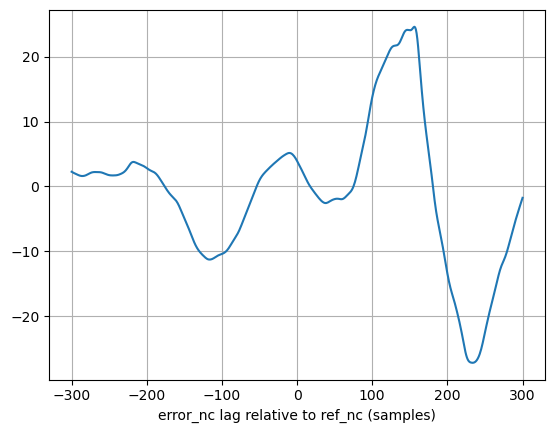

Peak: 233 samples = 2.4270833333333335 ms


In [19]:
from scipy.signal import correlate, correlation_lags

N = int(min(5 * fs, len(ref_nc), len(error_nc)))

x = ref_nc[:N] - np.mean(ref_nc[:N])
d = error_nc[:N] - np.mean(error_nc[:N])

corr = correlate(d, x, mode="full", method="fft")
lags = correlation_lags(len(d), len(x), mode="full")

mask = (lags >= -300) & (lags <= 300)

plt.plot(lags[mask], corr[mask])
plt.xlabel("error_nc lag relative to ref_nc (samples)")
plt.grid()
plt.show()

lag = lags[mask][np.argmax(np.abs(corr[mask]))]
print("Peak:", lag, "samples =", 1000 * lag / fs, "ms")

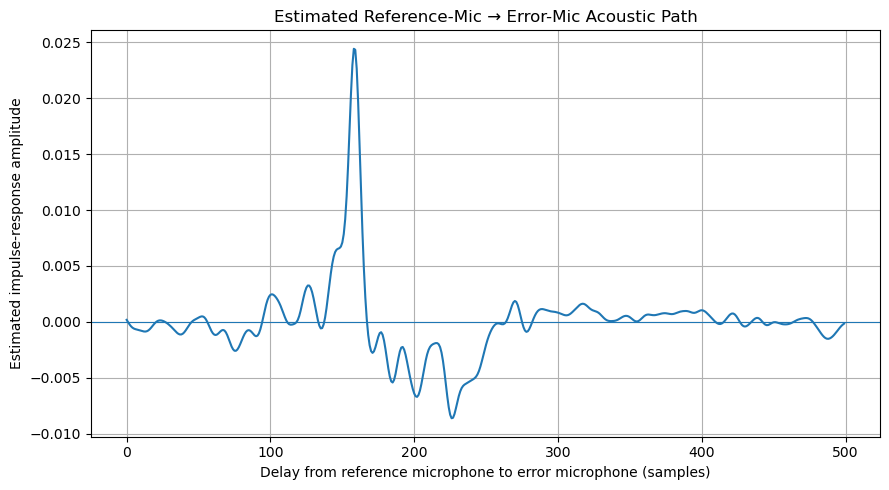

In [22]:
from scipy.signal import fftconvolve

N = int(min(5 * fs, len(ref_nc), len(error_nc)))
x = ref_nc[:N].astype(np.float64)
d = error_nc[:N].astype(np.float64)

x -= x.mean()
d -= d.mean()

# Frequency-domain regularized deconvolution
nfft = 1 << int(np.ceil(np.log2(N)))

X = np.fft.rfft(x, nfft)
D = np.fft.rfft(d, nfft)

reg = 1e-3 * np.max(np.abs(X)**2)

H = D * np.conj(X) / (np.abs(X)**2 + reg)
h = np.fft.irfft(H, nfft)

plt.figure(figsize=(9, 5))
plt.plot(np.arange(500), h[:500])

plt.axhline(0, linewidth=0.8)

plt.xlabel("Delay from reference microphone to error microphone (samples)")
plt.ylabel("Estimated impulse-response amplitude")
plt.title("Estimated Reference-Mic → Error-Mic Acoustic Path")

plt.grid(True)
plt.tight_layout()
plt.show()

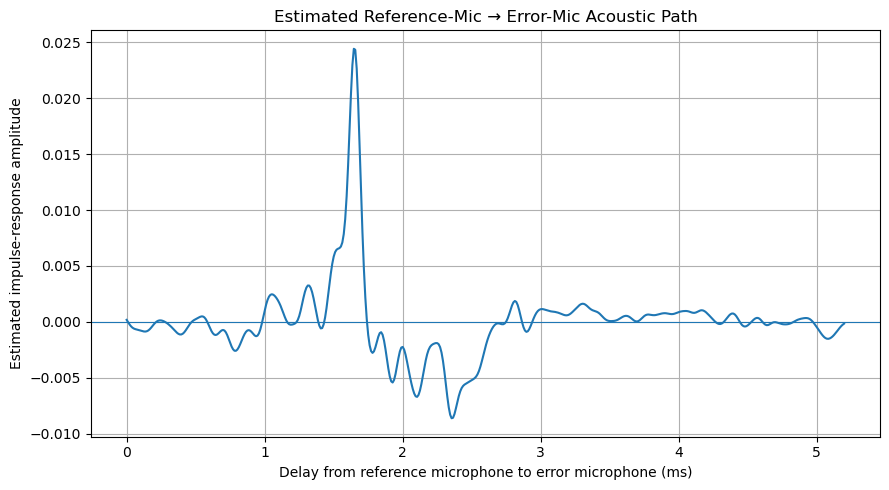

In [23]:
n = np.arange(500)
t_ms = 1000 * n / fs

plt.figure(figsize=(9, 5))
plt.plot(t_ms, h[:500])

plt.axhline(0, linewidth=0.8)

plt.xlabel("Delay from reference microphone to error microphone (ms)")
plt.ylabel("Estimated impulse-response amplitude")
plt.title("Estimated Reference-Mic → Error-Mic Acoustic Path")

plt.grid(True)
plt.tight_layout()
plt.show()

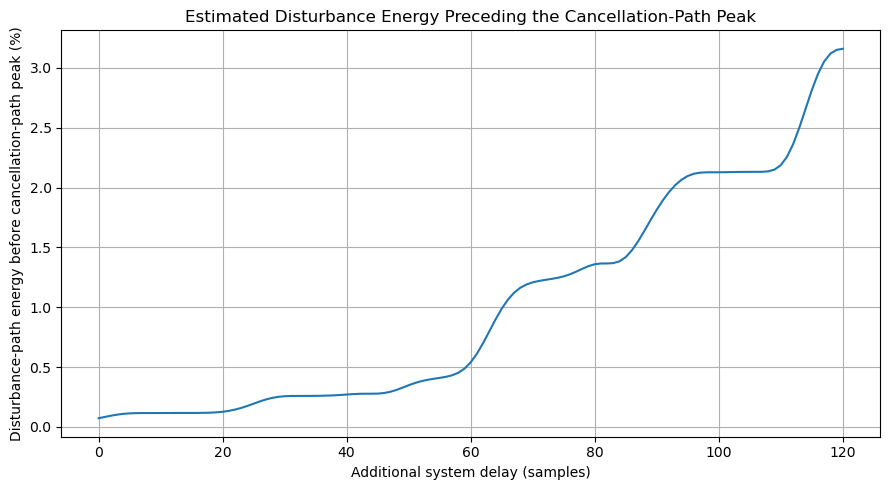

In [24]:
# How much estimated disturbance-path energy occurs too early
# for each simulated system delay?

max_system_delay = 120
error_ir_peak = np.argmax(np.abs(error_ir))   # should be ~13

# Use the same portion of h we were inspecting
h_use = h[:500]

total_energy = np.sum(h_use**2)

system_delays = np.arange(max_system_delay + 1)
too_early_fraction = np.zeros_like(system_delays, dtype=float)

for i, D in enumerate(system_delays):
    # Earliest dominant timing of the cancellation path
    boundary = D + error_ir_peak

    too_early_fraction[i] = (
        np.sum(h_use[:boundary]**2) / total_energy
    )

plt.figure(figsize=(9, 5))
plt.plot(system_delays, 100 * too_early_fraction)

plt.xlabel("Additional system delay (samples)")
plt.ylabel("Disturbance-path energy before cancellation-path peak (%)")
plt.title("Estimated Disturbance Energy Preceding the Cancellation-Path Peak")

plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
for D in range(0, 121, 10):
    print(
        f"D={D:3d}: "
        f"{100 * too_early_fraction[D]:5.1f}% before "
        f"sample {D + error_ir_peak}"
    )

D=  0:   0.1% before sample 13
D= 10:   0.1% before sample 23
D= 20:   0.1% before sample 33
D= 30:   0.3% before sample 43
D= 40:   0.3% before sample 53
D= 50:   0.3% before sample 63
D= 60:   0.5% before sample 73
D= 70:   1.2% before sample 83
D= 80:   1.4% before sample 93
D= 90:   1.8% before sample 103
D=100:   2.1% before sample 113
D=110:   2.2% before sample 123
D=120:   3.2% before sample 133


In [26]:
import numpy as np
from scipy.signal import lfilter


def least_squares_controller(
    ref_nc,
    error_nc,
    error_ir,
    M=1024,
    system_delay=86,
    cancel_gain=0.11,
    ridge=1e-2,
    trim=5000,
):
    """
    Find the optimal fixed M-tap controller for:

        control[n] = -cancel_gain * sum_k w[k] * ref[n-k]

        panel[n] = error_ir * control[n-system_delay]

        simulated_error[n] = error_nc[n] + panel[n]

    This matches the timing/sign convention of OfflineFxLMS.process_array().
    """

    x = np.asarray(ref_nc, dtype=np.float64)
    d = np.asarray(error_nc, dtype=np.float64)
    s = np.asarray(error_ir, dtype=np.float64)

    N = min(len(x), len(d))
    x = x[:N]
    d = d[:N]

    # Filtered reference through the measured secondary path.
    xf = lfilter(s, [1.0], x)

    # Explicit system latency, exactly like process_array().
    xf_delayed = np.zeros_like(xf)

    if system_delay > 0:
        xf_delayed[system_delay:] = xf[:-system_delay]
    else:
        xf_delayed[:] = xf

    # Throw away startup/transient region.
    start = max(trim, system_delay + len(s) + M)
    stop = N

    y = d[start:stop]

    # Build X such that:
    #
    # X @ w = sum_k w[k] * xf_delayed[n-k]
    #
    # Then actual panel contribution is:
    #
    #     -cancel_gain * X @ w
    #
    # We want:
    #
    #     d - cancel_gain * X @ w ~= 0

    from numpy.lib.stride_tricks import sliding_window_view

    windows = sliding_window_view(xf_delayed, M)

    # windows[j] = [xf[j], ..., xf[j+M-1]]
    # Reverse so each row is:
    # [xf[n], xf[n-1], ..., xf[n-M+1]]

    X_all = windows[:, ::-1]

    # Row corresponding to time n has index n-M+1.
    row_start = start - M + 1
    row_stop = stop - M + 1

    X = X_all[row_start:row_stop]

    assert len(X) == len(y)

    # Solve:
    #
    # min_w || d - cancel_gain*Xw ||^2 + ridge*||w||^2
    #
    # Divide the target by gain so the regression is:
    #
    # Xw ~= d / cancel_gain

    target = y / cancel_gain

    XtX = X.T @ X
    Xty = X.T @ target

    w = np.linalg.solve(
        XtX + ridge * np.eye(M),
        Xty,
    )

    # Evaluate using the SAME forward model.
    controller_raw = lfilter(w, [1.0], x)
    control = -cancel_gain * controller_raw

    delayed_control = np.zeros_like(control)

    if system_delay > 0:
        delayed_control[system_delay:] = control[:-system_delay]
    else:
        delayed_control[:] = control

    panel = lfilter(s, [1.0], delayed_control)

    simulated_error = d + panel

    # Evaluate over same region used for fitting.
    d_eval = d[start:stop]
    e_eval = simulated_error[start:stop]

    db = 10 * np.log10(
        (np.mean(e_eval**2) + 1e-20) /
        (np.mean(d_eval**2) + 1e-20)
    )

    print(f"system delay: {system_delay} samples")
    print(f"LS reduction: {db:.2f} dB")
    print(f"weight norm: {np.linalg.norm(w):.4f}")

    return w, simulated_error, control, panel, db

In [33]:
ref_short, error_short = trim(2)

In [ ]:
w_ls, e_ls, control_ls, panel_ls, db_ls = least_squares_controller(
    ref_short,
    error_short,
    error_ir=error_ir,
    M=1024,
    system_delay=0,
    cancel_gain=0.11,
    ridge=1e-2,
)

system delay: 0 samples
LS reduction: -18.90 dB
weight norm: 17.4080


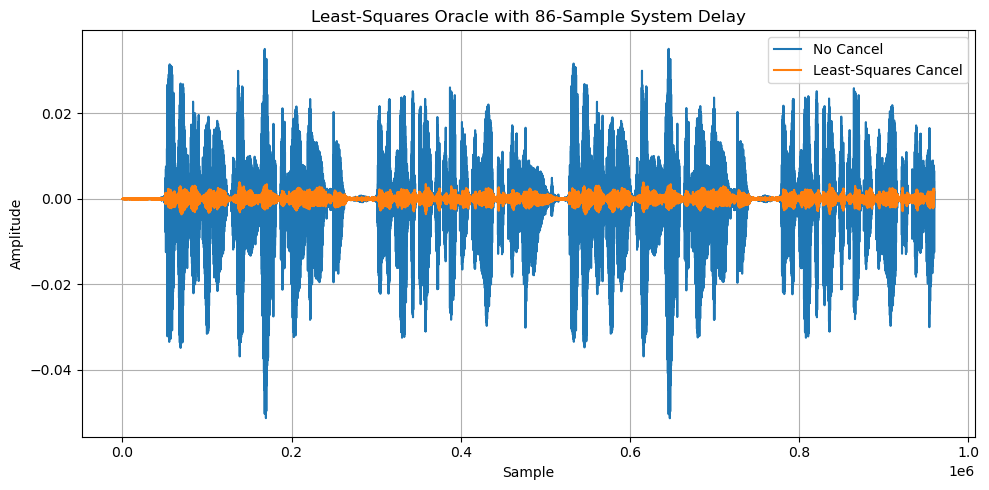

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(error_short, label="No Cancel")
plt.plot(e_ls, label="Least-Squares Cancel")

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Least-Squares Oracle with 86-Sample System Delay")

plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [74]:
w_ls, e_ls, control_ls, panel_ls, db_ls = least_squares_controller(
    ref_short,
    error_short,
    error_ir=error_ir,
    M=1024,
    system_delay=86,
    cancel_gain=0.11,
    ridge=1e-2,
)

system delay: 86 samples
LS reduction: -19.46 dB
weight norm: 17.3910


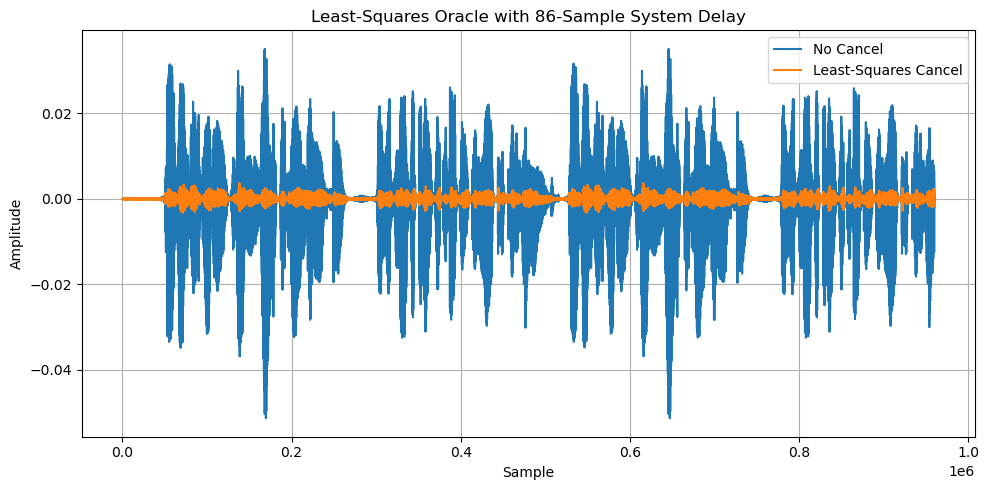

In [75]:
plt.figure(figsize=(10, 5))

plt.plot(error_short, label="No Cancel")
plt.plot(e_ls, label="Least-Squares Cancel")

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Least-Squares Oracle with 86-Sample System Delay")

plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()

Simulated ANC / No ANC: -19.46 dB


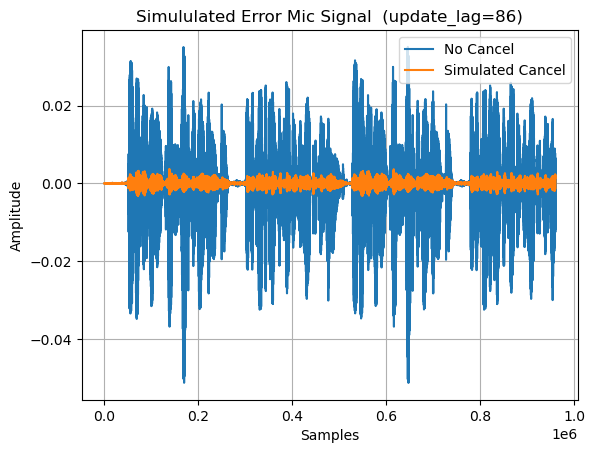

(array([-0.        , -0.        , -0.        , ..., -0.00226442,
        -0.00206499, -0.00178261], shape=(960000,), dtype=float32),
 array([ 0.0000000e+00, -3.0517578e-05,  0.0000000e+00, ...,
         1.4915906e-03,  1.4779171e-03,  1.3790780e-03],
       shape=(960000,), dtype=float32),
 array([ 0.        ,  0.        ,  0.        , ...,  0.00100331,
         0.00037928, -0.00023835], shape=(960000,), dtype=float32),
 [array([ 0.0243505 , -0.01246362,  0.01012514, ..., -0.14869658,
          0.04464216,  0.54994204], shape=(1024,))])

In [60]:
fx.reset()
fx.w = w_ls
fx.process_array(
    ref_short, error_short, adapt=False,
    cancel_gain=.11, lag=86
)

Simulated ANC / No ANC: -2.71 dB


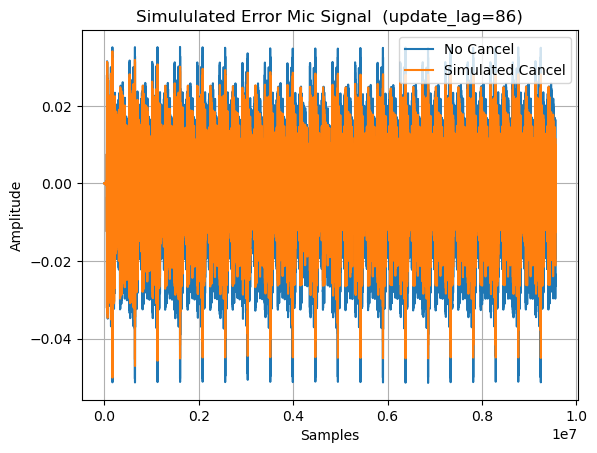

In [63]:
fx.reset()
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, adapt=True, save_weight_every_s=5,
    cancel_gain=.11, lag=86, mu=3e-4, leak=1e-6
)

In [69]:
dbs = []
for weights in weight_history:
    fx.reset()
    fx.w = weights
    _, simulated_error, _, _ = fx.process_array(
        ref_short, error_short, adapt=False, plot=False,
        cancel_gain=.11, lag=86
    )

    dbs.append(10 * np.log10(
        (np.mean(simulated_error**2) + 1e-20) /
        (np.mean(error_short**2) + 1e-20)
    ))

    

Simulated ANC / No ANC: -2.13 dB
Simulated ANC / No ANC: -2.45 dB
Simulated ANC / No ANC: -2.13 dB
Simulated ANC / No ANC: -2.53 dB
Simulated ANC / No ANC: -2.74 dB
Simulated ANC / No ANC: -2.86 dB
Simulated ANC / No ANC: -2.93 dB
Simulated ANC / No ANC: -2.97 dB
Simulated ANC / No ANC: -2.99 dB
Simulated ANC / No ANC: -2.96 dB
Simulated ANC / No ANC: -2.94 dB
Simulated ANC / No ANC: -2.95 dB
Simulated ANC / No ANC: -2.97 dB
Simulated ANC / No ANC: -2.98 dB
Simulated ANC / No ANC: -3.00 dB
Simulated ANC / No ANC: -3.00 dB
Simulated ANC / No ANC: -3.00 dB
Simulated ANC / No ANC: -3.00 dB
Simulated ANC / No ANC: -3.00 dB
Simulated ANC / No ANC: -3.00 dB


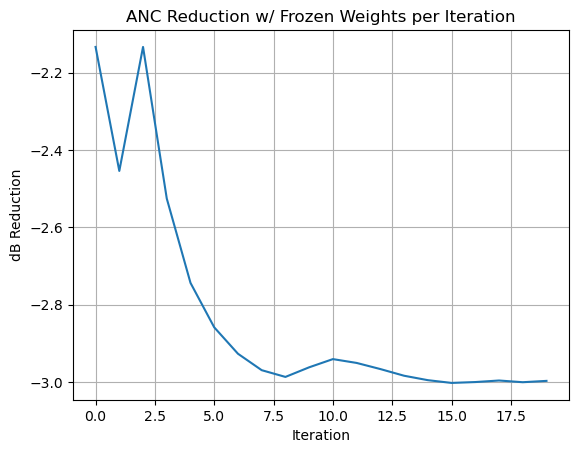

In [70]:
plt.plot(dbs)
plt.title('ANC Reduction w/ Frozen Weights per Iteration')
plt.xlabel('Iteration')
plt.ylabel('dB Reduction')
plt.grid(True)
plt.show()

Simulated ANC / No ANC: -4.38 dB


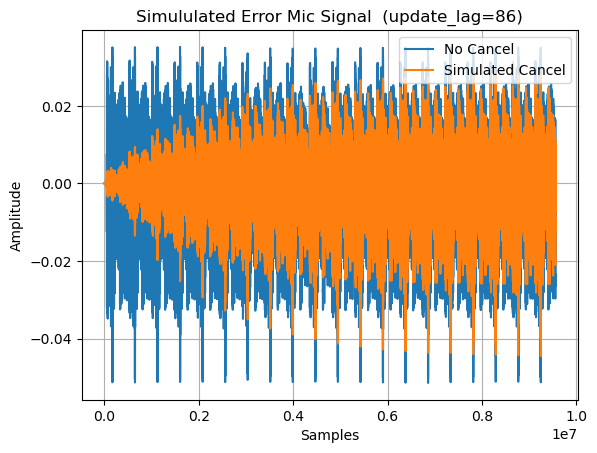

In [ ]:
fx.reset()
fx.w = w_ls.copy()
_ = fx.process_array(
    ref_nc, error_nc, adapt=True, save_weight_every_s=5,
    cancel_gain=.11, lag=86, mu=3e-4, leak=1e-6
)

Simulated ANC / No ANC: -12.70 dB


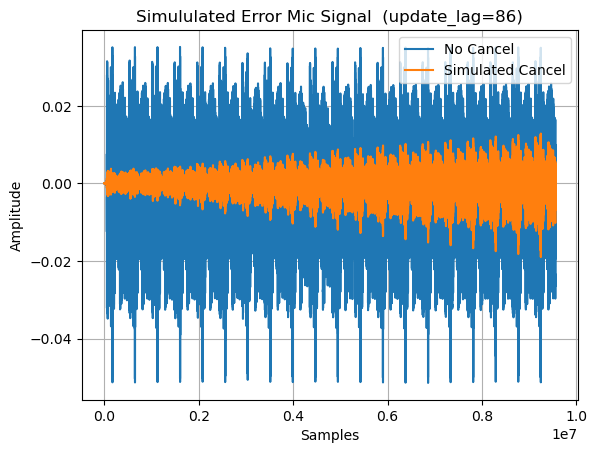

In [77]:
fx.reset()
fx.w = w_ls.copy()
_ = fx.process_array(
    ref_nc, error_nc, adapt=True, save_weight_every_s=5,
    cancel_gain=.11, lag=86, mu=1e-4, leak=1e-7
)

Simulated ANC / No ANC: -10.58 dB


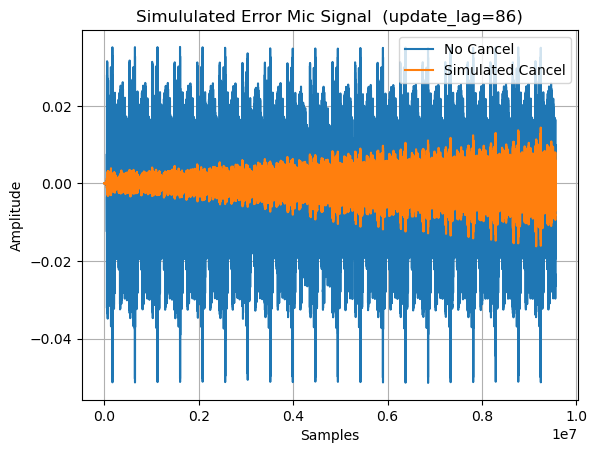

In [80]:
fx.reset()
fx.w = w_ls.copy()
_ = fx.process_array(
    ref_nc, error_nc, adapt=True, save_weight_every_s=5,
    cancel_gain=.11, lag=86, mu=1e-3, leak=0.0
)

In [85]:
from numpy.lib.stride_tricks import sliding_window_view

M = fx.M
system_delay = 86
cancel_gain = 0.11
ridge = 1e-2
trim = 5000


# ------------------------------------------------------------
# Build the exact delayed filtered-reference regression
# ------------------------------------------------------------

secondary_ir = np.asarray(error_ir, dtype=np.float64)

N = min(len(ref_short), len(error_short))

# Reference after secondary-path filtering
xf = lfilter(secondary_ir, [1.0], ref_short)

# Explicit system delay
xf_delayed = np.zeros_like(xf)

if system_delay > 0:
    xf_delayed[system_delay:] = xf[:-system_delay]
else:
    xf_delayed[:] = xf


# Each row becomes:
#
# [xf[n-D], xf[n-D-1], ..., xf[n-D-M+1]]
#
windows = sliding_window_view(xf_delayed, M)
X_all = windows[:, ::-1]

start = max(
    trim,
    system_delay + len(secondary_ir) + M
)

error_target = error_short[start:N]

row_start = start - M + 1
row_stop = N - M + 1

X = X_all[row_start:row_stop]

assert X.shape[0] == len(error_target)


# ------------------------------------------------------------
# Recompute least-squares controller
# ------------------------------------------------------------

# Our forward model is:
#
# e = error_target - cancel_gain * X @ w
#
# so LS wants:
#
# X @ w ~= error_target / cancel_gain

target = error_target / cancel_gain

XtX = X.T @ X
Xty = X.T @ target

w_ls_test = np.linalg.solve(
    XtX + ridge * np.eye(M),
    Xty
)


# Residual produced by that controller
e_ls = error_target - cancel_gain * (X @ w_ls_test)

db_ls = 10 * np.log10(
    (np.mean(e_ls**2) + 1e-20) /
    (np.mean(error_target**2) + 1e-20)
)

print(f"LS reduction: {db_ls:.2f} dB")
print(f"LS weight norm: {np.linalg.norm(w_ls_test):.6f}")

LS reduction: -19.46 dB
LS weight norm: 17.390999


In [87]:
xnorm = np.sum(X * X, axis=1)

mean_update_nlms = (
    X.T @ (e_ls / (fx.eps + xnorm))
) / len(e_ls)

print("||mean NLMS update||:",
      np.linalg.norm(mean_update_nlms))

print("relative mean NLMS update:",
      np.linalg.norm(mean_update_nlms) /
      (np.linalg.norm(w_ls) + 1e-20))

print("NLMS update · w_ls:",
      np.dot(mean_update_nlms, w_ls))

||mean NLMS update||: 0.0013415247606668487
relative mean NLMS update: 7.713902984572816e-05
NLMS update · w_ls: -0.00019786256866617178


In [88]:
# Energy of the actual regressor used for each update
xnorm_matched = np.sum(X**2, axis=1)

eps = float(fx.eps)

weighted_error = e_ls / (eps + xnorm_matched)

mean_nlms_update = (
    X.T @ weighted_error
) / len(e_ls)

print("\n--- Matched NLMS gradient test ---")
print("||mean update||:",
      np.linalg.norm(mean_nlms_update))

print("relative to ||w_ls||:",
      np.linalg.norm(mean_nlms_update) /
      (np.linalg.norm(w_ls_test) + 1e-20))

print("update dot w_ls:",
      np.dot(mean_nlms_update, w_ls_test))


--- Matched NLMS gradient test ---
||mean update||: 0.0013415247606668487
relative to ||w_ls||: 7.713902925171397e-05
update dot w_ls: -0.00019786257157641221


In [89]:
# ------------------------------------------------------------
# LMS mean update at w_ls
# ------------------------------------------------------------

mean_lms_update = (X.T @ e_ls) / len(e_ls)

print("--- LMS ---")
print("||mean update||:", np.linalg.norm(mean_lms_update))
print(
    "relative mean update:",
    np.linalg.norm(mean_lms_update) /
    (np.linalg.norm(w_ls_test) + 1e-20)
)
print(
    "update · w_ls:",
    np.dot(mean_lms_update, w_ls_test)
)


# ------------------------------------------------------------
# Matched NLMS mean update at w_ls
# ------------------------------------------------------------

xnorm_matched = np.sum(X**2, axis=1)

mean_nlms_update = (
    X.T @ (e_ls / (float(fx.eps) + xnorm_matched))
) / len(e_ls)

print("\n--- Matched NLMS ---")
print("||mean update||:", np.linalg.norm(mean_nlms_update))
print(
    "relative mean update:",
    np.linalg.norm(mean_nlms_update) /
    (np.linalg.norm(w_ls_test) + 1e-20)
)
print(
    "update · w_ls:",
    np.dot(mean_nlms_update, w_ls_test)
)

--- LMS ---
||mean update||: 2.0031359527216654e-08
relative mean update: 1.1518234130493967e-09
update · w_ls: 3.4836534760463017e-07

--- Matched NLMS ---
||mean update||: 0.0013415247606668487
relative mean update: 7.713902925171397e-05
update · w_ls: -0.00019786257157641221


In [90]:
mu = 1e-3

w_after_lms = w_ls_test + mu * mean_lms_update
w_after_nlms = w_ls_test + mu * mean_nlms_update

def residual_db(w):
    e = error_target - cancel_gain * (X @ w)
    return 10 * np.log10(
        (np.mean(e**2) + 1e-20) /
        (np.mean(error_target**2) + 1e-20)
    )

print("LS optimum:", residual_db(w_ls_test))
print("after mean LMS step:", residual_db(w_after_lms))
print("after mean NLMS step:", residual_db(w_after_nlms))

LS optimum: -19.45753055611453
after mean LMS step: -19.457530556115394
after mean NLMS step: -19.457530555602382


In [ ]:
fx.reset()
fx.lag = 86
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, adapt=True, clean_feedback=False, save_weight_every_s=5
)

Simulated ANC / No ANC: 6.71 dB


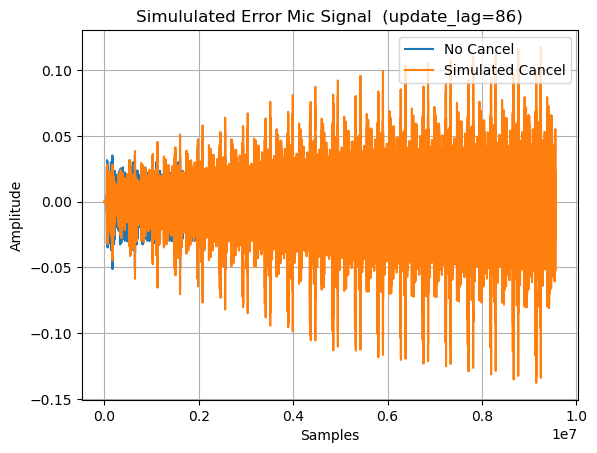

In [5]:
db_reduction = 10 * np.log10(
    (np.mean(simulated_error**2) + 1e-20) /
    (np.mean(error_nc**2) + 1e-20)
)

print(f"Simulated ANC / No ANC: {db_reduction:.2f} dB")


plt.plot(error_nc, label="No Cancel")
plt.plot(simulated_error, label="Simulated Cancel")

plt.title(f"Simululated Error Mic Signal  (update_lag={fx.lag})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [6]:
fx.reset()
fx.lag = 86
system_delay = 86
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, adapt=True, clean_feedback=False, save_weight_every_s=5, system_delay=system_delay
)

Simulated ANC / No ANC: 5.39 dB


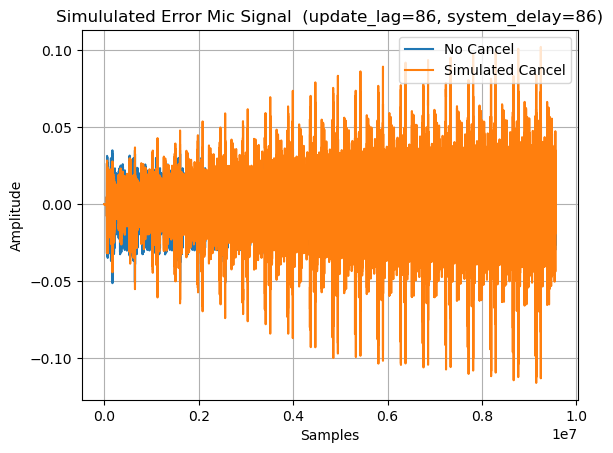

In [7]:
db_reduction = 10 * np.log10(
    (np.mean(simulated_error**2) + 1e-20) /
    (np.mean(error_nc**2) + 1e-20)
)

print(f"Simulated ANC / No ANC: {db_reduction:.2f} dB")


plt.plot(error_nc, label="No Cancel")
plt.plot(simulated_error, label="Simulated Cancel")

plt.title(f"Simululated Error Mic Signal  (update_lag={fx.lag}, system_delay={system_delay})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [8]:
fx.reset()
fx.lag = 0
system_delay = 0
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, adapt=True, clean_feedback=False, save_weight_every_s=5, system_delay=system_delay
)

Simulated ANC / No ANC: -9.40 dB


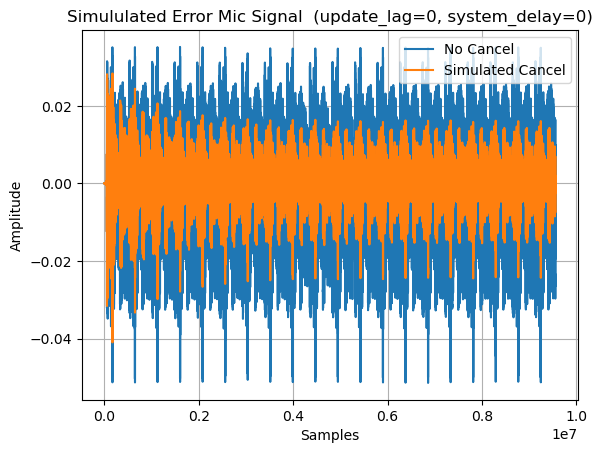

In [9]:
db_reduction = 10 * np.log10(
    (np.mean(simulated_error**2) + 1e-20) /
    (np.mean(error_nc**2) + 1e-20)
)

print(f"Simulated ANC / No ANC: {db_reduction:.2f} dB")


plt.plot(error_nc, label="No Cancel")
plt.plot(simulated_error, label="Simulated Cancel")

plt.title(f"Simululated Error Mic Signal  (update_lag={fx.lag}, system_delay={system_delay})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [10]:
fx.reset()
fx.lag = 0
system_delay = 86
control, simulated_error, panel_output, weight_history = fx.process_array(
    ref_nc, error_nc, adapt=True, clean_feedback=False, save_weight_every_s=5, system_delay=system_delay
)

C:\Users\rnbow\AppData\Local\Temp\ipykernel_8784\2150626182.py:2: RuntimeWarning: overflow encountered in square
  (np.mean(simulated_error**2) + 1e-20) /


Simulated ANC / No ANC: nan dB


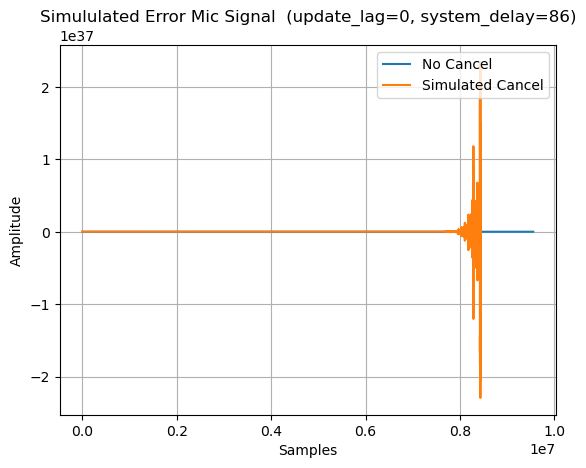

In [11]:
db_reduction = 10 * np.log10(
    (np.mean(simulated_error**2) + 1e-20) /
    (np.mean(error_nc**2) + 1e-20)
)

print(f"Simulated ANC / No ANC: {db_reduction:.2f} dB")


plt.plot(error_nc, label="No Cancel")
plt.plot(simulated_error, label="Simulated Cancel")

plt.title(f"Simululated Error Mic Signal  (update_lag={fx.lag}, system_delay={system_delay})")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [5]:
def debug_control_timing(
    fx,
    panel_ir,
    system_delay=86,
    impulse_index=1000,
    weight_index=0,
    weight_value=1.0,
):
    N = impulse_index + system_delay + len(panel_ir) + 20

    ref = np.zeros(N, dtype=fx.dtype)
    error_nc = np.zeros(N, dtype=fx.dtype)

    ref[impulse_index] = 1.0

    fx.reset()
    fx.adapt = False

    fx.w[:] = 0.0
    fx.w[weight_index] = weight_value

    control = np.zeros(N, dtype=fx.dtype)
    delayed_control = np.zeros(N, dtype=fx.dtype)
    panel_output = np.zeros(N, dtype=fx.dtype)
    simulated_error = np.zeros(N, dtype=fx.dtype)

    panel_state = np.zeros(2 * len(panel_ir), dtype=fx.dtype)
    panel_head = 0

    delay_state = np.zeros(system_delay, dtype=fx.dtype) if system_delay > 0 else None
    delay_head = 0

    for n in range(N):
        control_n, _ = fx.compute_control(ref[n])
        control[n] = control_n

        if system_delay > 0:
            delayed_n = delay_state[delay_head]
            delay_state[delay_head] = control_n
            delay_head = (delay_head + 1) % system_delay
        else:
            delayed_n = control_n

        delayed_control[n] = delayed_n

        panel_n, panel_head = fx._ring_fir(
            delayed_n,
            panel_ir,
            panel_state,
            panel_head,
            len(panel_ir),
        )

        panel_output[n] = panel_n
        simulated_error[n] = error_nc[n] + panel_n

    return {
        "ref": ref,
        "control": control,
        "delayed_control": delayed_control,
        "panel_output": panel_output,
        "simulated_error": simulated_error,
    }

In [6]:
test = debug_control_timing(
    fx,
    panel_ir=error_ir,
    system_delay=86,
    impulse_index=1000,
    weight_index=0,
    weight_value=1.0,
)

In [7]:
for name in ["ref", "control", "delayed_control", "panel_output"]:
    inds = np.where(np.abs(test[name]) > 1e-8)[0]
    print(name, inds[:10])

ref [1000]
control [1000]
delayed_control [1086]
panel_output [1086 1087 1088 1089 1090 1091 1092 1093 1094 1095]


In [8]:
print("control impulse:")
print(test["control"][1000])

print("expected:")
print(-fx.cancel_gain)

print()

print("panel first samples:")
print(test["panel_output"][1086:1091])

print("expected:")
print(-fx.cancel_gain * error_ir[:5])

control impulse:
-0.24
expected:
-0.24

panel first samples:
[-5.2021456e-05 -5.5140404e-06  1.7736902e-05 -3.4460754e-05
 -7.6187243e-05]
expected:
[-5.2021456e-05 -5.5140404e-06  1.7736902e-05 -3.4460754e-05
 -7.6187243e-05]


In [9]:
test = debug_control_timing(
    fx,
    panel_ir=error_ir,
    system_delay=86,
    impulse_index=1000,
    weight_index=20,
    weight_value=1.0,
)

In [12]:
def test_frozen_tap(
    fx,
    ref_nc,
    error_nc,
    error_ir,
    tap,
    system_delay=86,
    trim=5000,
):
    fx.reset()
    fx.adapt = False

    old_gain = fx.cancel_gain
    fx.cancel_gain = fx.dtype(1.0)

    fx.w[:] = 0.0
    fx.w[tap] = 1.0

    control, delayed_control, panel_output, _ = simulate_frozen_controller(
        fx,
        ref_nc,
        error_nc,
        error_ir,
        system_delay,
    )

    # Ignore startup transient
    d = error_nc[trim:]
    p = panel_output[trim:]

    # Find scalar a minimizing ||d + a*p||^2
    a = -np.dot(d, p) / (np.dot(p, p) + 1e-20)

    simulated_error = error_nc.copy()
    simulated_error[trim:] = d + a * p

    db = 10 * np.log10(
        (np.mean(simulated_error[trim:] ** 2) + 1e-20) /
        (np.mean(error_nc[trim:] ** 2) + 1e-20)
    )

    fx.cancel_gain = old_gain

    return a, db, panel_output, simulated_error

In [13]:
a, db, panel_output, simulated_error = test_frozen_tap(
    fx,
    ref_nc,
    error_nc,
    error_ir,
    tap=0,
    system_delay=86,
)

print("optimal coefficient:", a)
print("reduction:", db, "dB")

optimal coefficient: 0.57833403
reduction: -0.58872604 dB


In [15]:
from scipy.signal import lfilter

system_delay = 86
trim = 5000

# ref passed through secondary-path IR
p0 = lfilter(error_ir, [1.0], ref_nc)

# add explicit system delay
p = np.zeros_like(p0)

if system_delay > 0:
    p[system_delay:] = p0[:-system_delay]
else:
    p[:] = p0

In [17]:
results = []

N = min(len(ref_nc), len(error_nc))

for tap in range(fx.M):

    total_delay = system_delay + tap

    # secondary response before explicit/controller delays
    base = lfilter(error_ir, [1.0], ref_nc[:N])

    # compare:
    # disturbance at time n
    # against base response generated total_delay samples earlier
    d_seg = error_nc[trim + total_delay:N]
    p_seg = base[trim:N - total_delay]

    a = -np.dot(d_seg, p_seg) / (np.dot(p_seg, p_seg) + 1e-20)

    e_seg = d_seg + a * p_seg

    db = 10 * np.log10(
        (np.mean(e_seg**2) + 1e-20) /
        (np.mean(d_seg**2) + 1e-20)
    )

    results.append((tap, a, db))

In [18]:
best = min(results, key=lambda x: x[2])

print("best tap:", best[0])
print("best coefficient:", best[1])
print("best reduction:", best[2], "dB")

best tap: 47
best coefficient: -1.2129100698114252
best reduction: -3.5422203403456463 dB


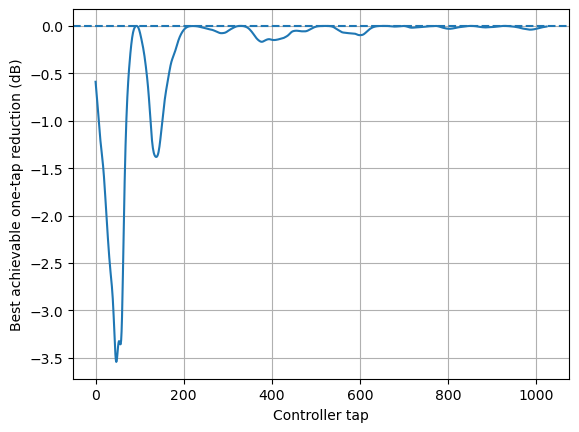

In [19]:
taps = np.array([r[0] for r in results])
db = np.array([r[2] for r in results])

plt.figure()
plt.plot(taps, db)
plt.axhline(0, linestyle="--")
plt.xlabel("Controller tap")
plt.ylabel("Best achievable one-tap reduction (dB)")
plt.grid()
plt.show()